In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# # Download from Zenodo
# !wget https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip

# # Unzip
# !unzip -o weights_pneumoniamnist.zip

# import shutil
# shutil.copy('resnet18_224_1.pth', '/content/drive/MyDrive/resnet_18_weights_folder_iter1/resnet18_224_1.pth')
# print('Weights saved to Google Drive!')

## Use the code below when Google Colab resets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

path_to_model = '/content/drive/MyDrive/resnet_18_weights_folder_iter1/resnet18_224_1.pth'

model = models.resnet18()
model.fc = torch.nn.Linear(512, 2)

# MedMNIST saves weights under a 'net' key
state_dict = torch.load(path_to_model, map_location=device)
model.load_state_dict(state_dict['net'])

model = model.to(device)
model.eval()
print('Model loaded successfully!')

Mounted at /content/drive
Using device: cuda
Model loaded successfully!


In [4]:
# confirmation
import os
print(os.path.exists('/content/drive/MyDrive/resnet_18_weights_folder_iter1/resnet18_224_1.pth'))

True


In [5]:
# Install dependencies
!pip install medmnist scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.5 MB/s eta 0:00:00


In [6]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST
from torch.utils.data import DataLoader
from medmnist import Evaluator
import numpy as np
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score, accuracy_score

print('All libraries loaded!')

All libraries loaded!


In [7]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])
])

# size=224 tells MedMNIST to use native 224x224 images
test_dataset = PneumoniaMNIST(split='test', transform=transform, download=True, size=224)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f'Test set loaded: {len(test_dataset)} images')

100%|██████████| 214M/214M [00:16<00:00, 12.7MB/s]


Test set loaded: 624 images


In [8]:
# Get a batch from the test loader
images, labels = next(iter(test_loader))

print(f'Batch shape: {images.shape}')
print(f'Single image shape: {images[0].shape}')
print(f'Number of images in batch: {images.shape[0]}')
print(f'Number of channels: {images.shape[1]}')
print(f'Height: {images.shape[2]}')
print(f'Width: {images.shape[3]}')
print(f'Pixel value range: min={images.min():.4f}, max={images.max():.4f}')

Batch shape: torch.Size([32, 3, 224, 224])
Single image shape: torch.Size([3, 224, 224])
Number of images in batch: 32
Number of channels: 3
Height: 224
Width: 224
Pixel value range: min=-1.0000, max=1.0000


In [9]:
import os
print(os.path.exists('/root/.medmnist/pneumoniamnist_224.npz'))  # Should print True

True


In [10]:
# setting up the attack functions
def brightness_attack(images, delta):
    """
    Brightness shift attack.
    Adds delta to every pixel.
    Positive delta = brighter, Negative delta = darker
    """
    perturbed = images + delta
    return torch.clamp(perturbed, -1, 1)


def contrast_attack(images, alpha):
    """
    Contrast shift attack.
    Scales every pixel by alpha.
    alpha > 1 = more contrast, alpha < 1 = less contrast
    """
    perturbed = alpha * images
    return torch.clamp(perturbed, -1, 1)

print('Attack functions defined!')

Attack functions defined!


In [11]:
# evaluation function
def evaluate(model, loader, attack_fn=None, attack_param=None):
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long()

            # Apply attack if specified
            if attack_fn is not None:
                images = attack_fn(images, attack_param)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, all_preds)

    # Now also return labels and preds so we can use them outside
    return auc, acc, all_labels, all_preds

In [12]:
# checking
clean_auc, clean_acc, clean_labels, clean_preds = evaluate(model, test_loader)
print(f'Clean Baseline — AUC: {clean_auc:.4f} | Accuracy: {clean_acc:.4f}')

Clean Baseline — AUC: 0.9553 | Accuracy: 0.8942


In [13]:
# brightness attack

brightness_deltas = [-0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

brightness_aucs = []
brightness_accs = []

for delta in brightness_deltas:
    auc, acc, _, _ = evaluate(model, test_loader, attack_fn=brightness_attack, attack_param=delta)
    brightness_aucs.append(auc)
    brightness_accs.append(acc)
    print(f'Delta={delta:+.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Delta=-0.5 — AUC: 0.9369 | ACC: 0.8029
Delta=-0.4 — AUC: 0.9496 | ACC: 0.8494
Delta=-0.3 — AUC: 0.9566 | ACC: 0.8702
Delta=-0.2 — AUC: 0.9605 | ACC: 0.8814
Delta=-0.1 — AUC: 0.9593 | ACC: 0.8894
Delta=+0.0 — AUC: 0.9553 | ACC: 0.8942
Delta=+0.1 — AUC: 0.9459 | ACC: 0.8814
Delta=+0.2 — AUC: 0.9416 | ACC: 0.8574
Delta=+0.3 — AUC: 0.9377 | ACC: 0.8237
Delta=+0.4 — AUC: 0.9243 | ACC: 0.7869
Delta=+0.5 — AUC: 0.8903 | ACC: 0.7260


In [14]:
# constrast attack

contrast_alphas = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

contrast_aucs = []
contrast_accs = []

for alpha in contrast_alphas:
    auc, acc, _, _ = evaluate(model, test_loader, attack_fn=contrast_attack, attack_param=alpha)
    contrast_aucs.append(auc)
    contrast_accs.append(acc)
    print(f'Alpha={alpha:.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Alpha=0.2 — AUC: 0.6770 | ACC: 0.6266
Alpha=0.4 — AUC: 0.9305 | ACC: 0.7901
Alpha=0.6 — AUC: 0.9596 | ACC: 0.8702
Alpha=0.8 — AUC: 0.9569 | ACC: 0.8958
Alpha=1.0 — AUC: 0.9553 | ACC: 0.8942
Alpha=1.2 — AUC: 0.9524 | ACC: 0.8814
Alpha=1.4 — AUC: 0.9514 | ACC: 0.8766
Alpha=1.6 — AUC: 0.9481 | ACC: 0.8702
Alpha=1.8 — AUC: 0.9445 | ACC: 0.8622
Alpha=2.0 — AUC: 0.9391 | ACC: 0.8558


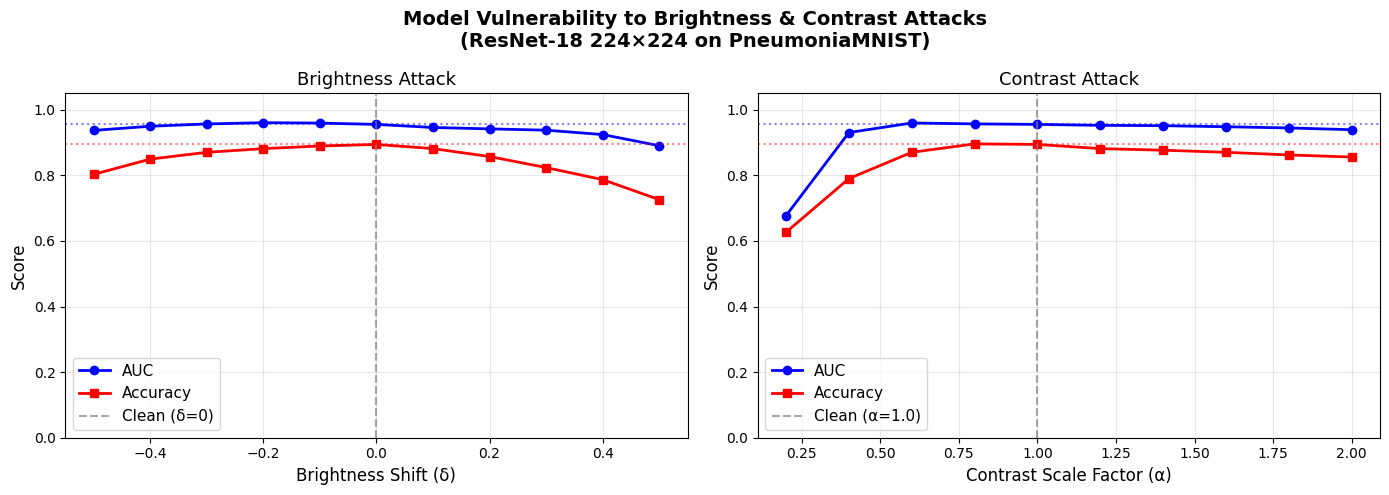

Vulnerability curves saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Vulnerability to Brightness & Contrast Attacks\n(ResNet-18 224×224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

# --- Brightness Plot ---
ax1 = axes[0]
ax1.plot(brightness_deltas, brightness_aucs, 'b-o', label='AUC', linewidth=2)
ax1.plot(brightness_deltas, brightness_accs, 'r-s', label='Accuracy', linewidth=2)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Clean (δ=0)')
ax1.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax1.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Brightness Shift (δ)', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Brightness Attack', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# --- Contrast Plot ---
ax2 = axes[1]
ax2.plot(contrast_alphas, contrast_aucs, 'b-o', label='AUC', linewidth=2)
ax2.plot(contrast_alphas, contrast_accs, 'r-s', label='Accuracy', linewidth=2)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7, label='Clean (α=1.0)')
ax2.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax2.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax2.set_xlabel('Contrast Scale Factor (α)', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Contrast Attack', fontsize=13)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vulnerability_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vulnerability curves saved!')

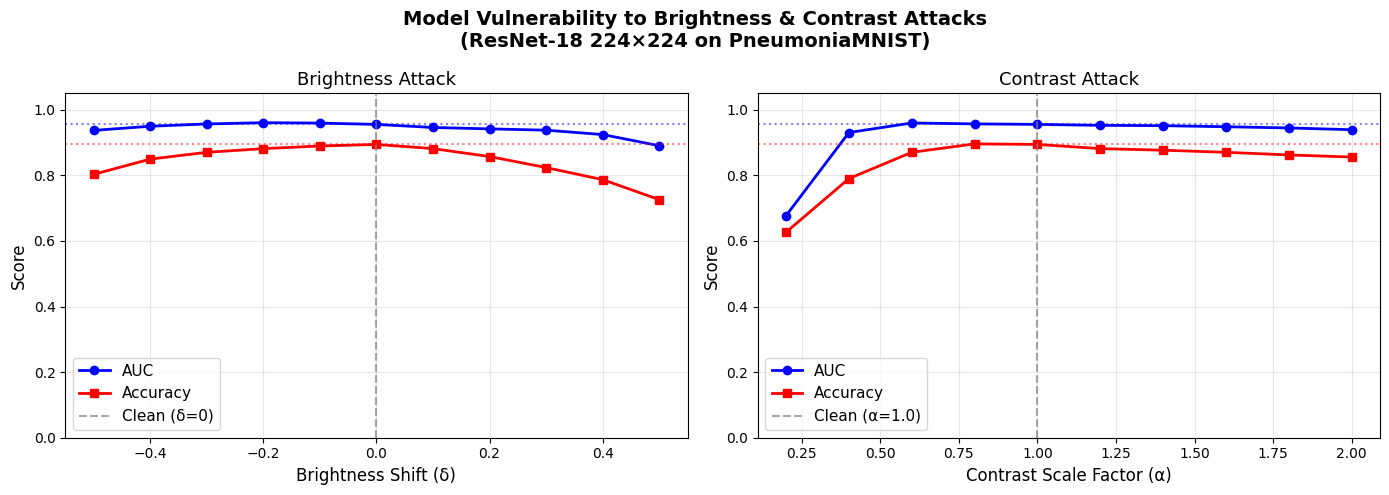

Vulnerability curves saved!


In [16]:
import matplotlib.pyplot as plt

# vulnerability curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Vulnerability to Brightness & Contrast Attacks\n(ResNet-18 224×224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

# Brightness plot
ax1 = axes[0]
ax1.plot(brightness_deltas, brightness_aucs, 'b-o', label='AUC', linewidth=2)
ax1.plot(brightness_deltas, brightness_accs, 'r-s', label='Accuracy', linewidth=2)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Clean (δ=0)')
ax1.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax1.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Brightness Shift (δ)', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Brightness Attack', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Contrast plot
ax2 = axes[1]
ax2.plot(contrast_alphas, contrast_aucs, 'b-o', label='AUC', linewidth=2)
ax2.plot(contrast_alphas, contrast_accs, 'r-s', label='Accuracy', linewidth=2)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7, label='Clean (α=1.0)')
ax2.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax2.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax2.set_xlabel('Contrast Scale Factor (α)', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Contrast Attack', fontsize=13)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vulnerability_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vulnerability curves saved!')

In [17]:
import shutil
shutil.copy('vulnerability_curves.png', '/content/drive/MyDrive/resnet_18_weights_folder_iter1/vulnerability_curves.png')
print('Plot saved to Google Drive!')

Plot saved to Google Drive!


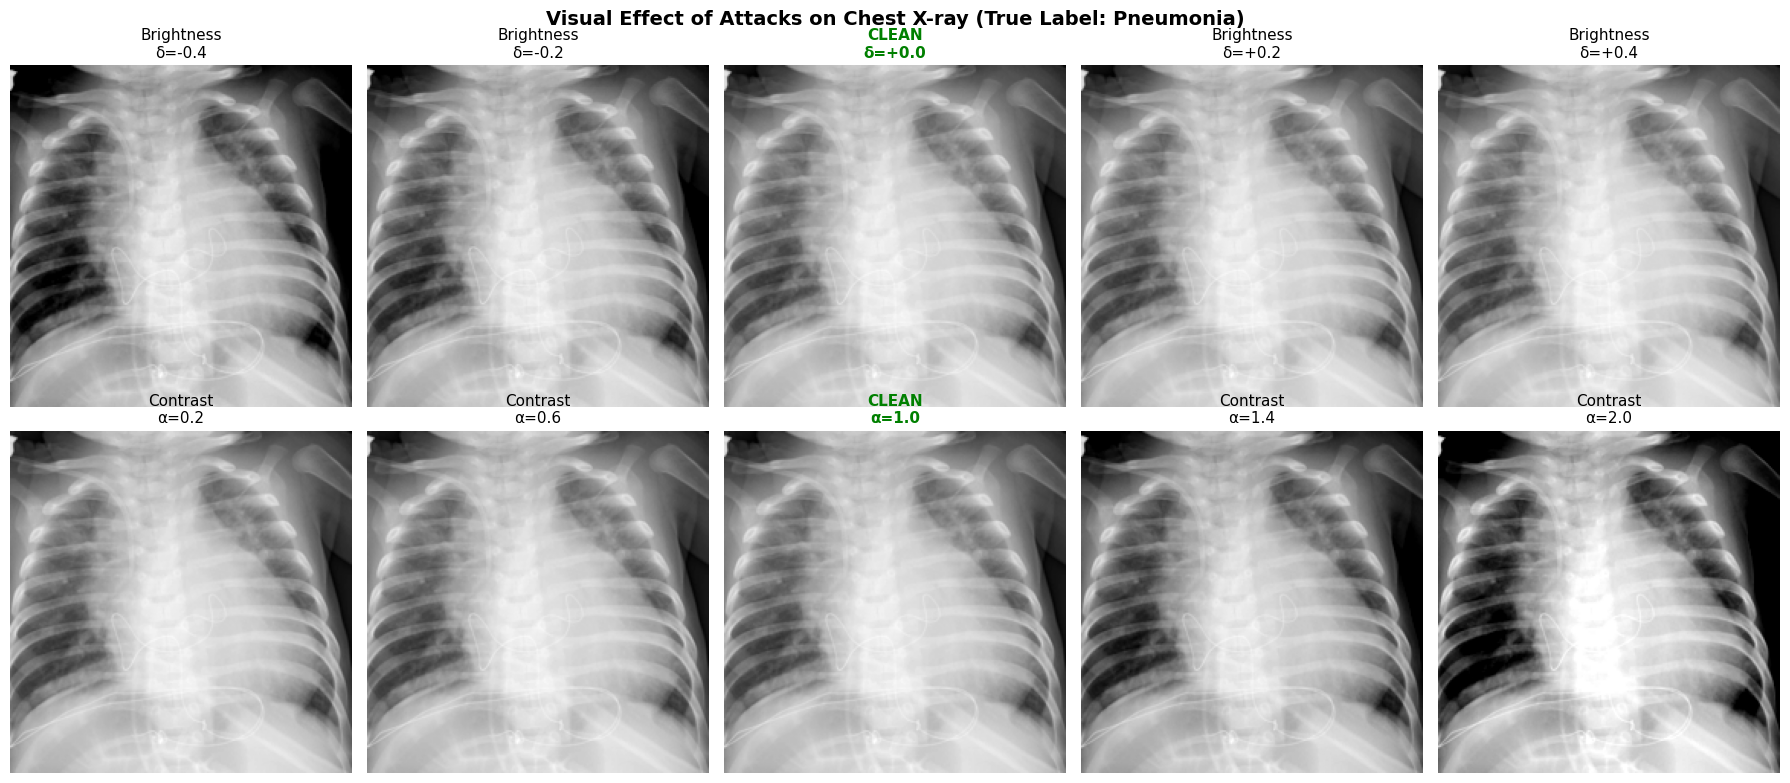

Visualization saved!


In [18]:
import matplotlib.pyplot as plt
import torch

# visualize attack effects on X-rays

def denormalize(tensor):
    """Convert normalized tensor back to [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Grab one sample X-ray from the test set
sample_images, sample_labels = next(iter(test_loader))
sample_img = sample_images[0].unsqueeze(0).to(device)
label_text = 'Pneumonia' if sample_labels[0].item() == 1 else 'Normal'

# Levels to visualize
viz_deltas = [-0.4, -0.2, 0.0, 0.2, 0.4]
viz_alphas = [0.2, 0.6, 1.0, 1.4, 2.0]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle(f'Visual Effect of Attacks on Chest X-ray (True Label: {label_text})',
             fontsize=14, fontweight='bold')

# Row 1: Brightness shifts
for i, delta in enumerate(viz_deltas):
    perturbed = brightness_attack(sample_img, delta)
    img_display = denormalize(perturbed.squeeze().cpu())[0]  # Take first channel
    axes[0, i].imshow(img_display, cmap='gray')
    if delta == 0.0:
        axes[0, i].set_title(f'CLEAN\nδ={delta:+.1f}', fontsize=11, color='green', fontweight='bold')
    else:
        axes[0, i].set_title(f'Brightness\nδ={delta:+.1f}', fontsize=11)
    axes[0, i].axis('off')

# Row 2: Contrast shifts
for i, alpha in enumerate(viz_alphas):
    perturbed = contrast_attack(sample_img, alpha)
    img_display = denormalize(perturbed.squeeze().cpu())[0]  # Take first channel
    axes[1, i].imshow(img_display, cmap='gray')
    if alpha == 1.0:
        axes[1, i].set_title(f'CLEAN\nα={alpha:.1f}', fontsize=11, color='green', fontweight='bold')
    else:
        axes[1, i].set_title(f'Contrast\nα={alpha:.1f}', fontsize=11)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('attack_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved!')

In [19]:
# Get a batch of images and labels from the test set
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.squeeze().long()

In [20]:
# which specific images fail first under attack
for delta in brightness_deltas:
    auc, acc, _, _ = evaluate(model, test_loader, attack_fn=brightness_attack, attack_param=delta)
    brightness_aucs.append(auc)
    brightness_accs.append(acc)
    print(f'Delta={delta:+.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Delta=-0.5 — AUC: 0.9369 | ACC: 0.8029
Delta=-0.4 — AUC: 0.9496 | ACC: 0.8494
Delta=-0.3 — AUC: 0.9566 | ACC: 0.8702
Delta=-0.2 — AUC: 0.9605 | ACC: 0.8814
Delta=-0.1 — AUC: 0.9593 | ACC: 0.8894
Delta=+0.0 — AUC: 0.9553 | ACC: 0.8942
Delta=+0.1 — AUC: 0.9459 | ACC: 0.8814
Delta=+0.2 — AUC: 0.9416 | ACC: 0.8574
Delta=+0.3 — AUC: 0.9377 | ACC: 0.8237
Delta=+0.4 — AUC: 0.9243 | ACC: 0.7869
Delta=+0.5 — AUC: 0.8903 | ACC: 0.7260


In [21]:
# does brightness shift cause more pneumonia cases (false negatives) or more false alarms (false positives)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(clean_labels, clean_preds)
print('Clean Baseline Confusion Matrix:')
print(f'True Negatives:  {cm[0,0]}')
print(f'False Positives: {cm[0,1]}')
print(f'False Negatives: {cm[1,0]}')
print(f'True Positives:  {cm[1,1]}')

Clean Baseline Confusion Matrix:
True Negatives:  178
False Positives: 56
False Negatives: 10
True Positives:  380


In [22]:
# what happens when I apply both the brightness and constrast attack simultaneously
def combined_attack(images, params):
    delta, alpha = params  # Unpack the tuple
    perturbed = alpha * images + delta
    return torch.clamp(perturbed, -1, 1)

# Test worst case combination
auc, acc, _, _ = evaluate(model, test_loader,
                    attack_fn=combined_attack,
                    attack_param=(0.3, 0.4))
print(f'Combined attack (delta=0.3, alpha=0.4) — AUC: {auc:.4f} | ACC: {acc:.4f}')

Combined attack (delta=0.3, alpha=0.4) — AUC: 0.8959 | ACC: 0.7260


In [23]:
# How confident is the model in its wrong predictions under attack?
perturbed = contrast_attack(images, alpha=0.2)
outputs = model(perturbed)
probs = torch.softmax(outputs, dim=1)
max_confidence = probs.max(dim=1).values
print(f'Average confidence under attack: {max_confidence.mean():.4f}')

Average confidence under attack: 1.0000


In [24]:
# Confusion matrix under worst case contrast attack (δ=+0.5 for brightness, α=0.2 for contrast)
auc, acc, attack_labels, attack_preds = evaluate(
    model, test_loader,
    attack_fn=contrast_attack,
    attack_param=0.2
)

cm_attack = confusion_matrix(attack_labels, attack_preds)
print('Contrast Attack (α=0.2) Confusion Matrix:')
print(f'True Negatives:  {cm_attack[0,0]}')
print(f'False Positives: {cm_attack[0,1]}')
print(f'False Negatives: {cm_attack[1,0]}')
print(f'True Positives:  {cm_attack[1,1]}')

Contrast Attack (α=0.2) Confusion Matrix:
True Negatives:  1
False Positives: 233
False Negatives: 0
True Positives:  390


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

# precision and recall under attack
precision = precision_score(attack_labels, attack_preds)
recall = recall_score(attack_labels, attack_preds)
f1 = f1_score(attack_labels, attack_preds)
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

Precision: 0.6260
Recall:    1.0000
F1 Score:  0.7700


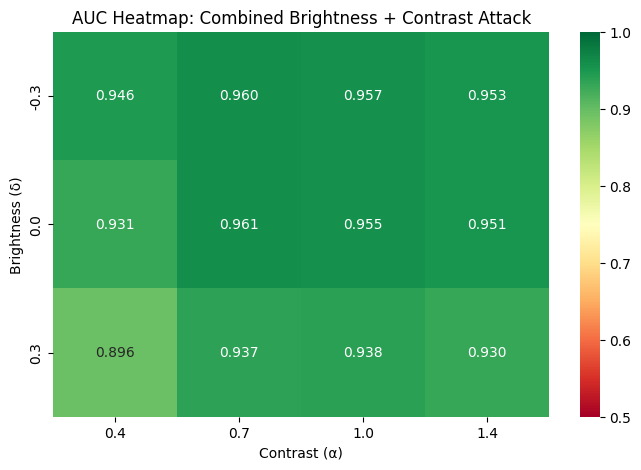

In [26]:
# testing a grid of delta and alpha values together and visualize as a heatmap
import numpy as np
import seaborn as sns

deltas = [-0.3, 0.0, 0.3]
alphas = [0.4, 0.7, 1.0, 1.4]

results = np.zeros((len(deltas), len(alphas)))

for i, delta in enumerate(deltas):
    for j, alpha in enumerate(alphas):
        auc, acc, _, _ = evaluate(model, test_loader,
                                   attack_fn=combined_attack,
                                   attack_param=(delta, alpha))
        results[i, j] = auc

plt.figure(figsize=(8, 5))
sns.heatmap(results,
            xticklabels=alphas,
            yticklabels=deltas,
            annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0)
plt.xlabel('Contrast (α)')
plt.ylabel('Brightness (δ)')
plt.title('AUC Heatmap: Combined Brightness + Contrast Attack')
plt.savefig('combined_attack_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# histogram equalization
import cv2
import numpy as np

def histogram_equalization(images):
    """Apply CLAHE preprocessing as a defense against contrast attacks."""
    # Convert tensor to numpy, apply CLAHE, convert back
    defended = []
    for img in images.cpu().numpy():
        img_uint8 = ((img[0] + 1) * 127.5).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        equalized = clahe.apply(img_uint8)
        equalized = (equalized / 127.5 - 1.0).astype(np.float32)
        defended.append(torch.tensor(equalized).unsqueeze(0).repeat(3, 1, 1))
    return torch.stack(defended).to(images.device)

## Gamma Correction attacks

In [28]:
def gamma_attack(images, gamma):
    """
    Gamma correction attack.
    gamma < 1 = brightens dark areas (overexposed look)
    gamma > 1 = darkens bright areas (underexposed look)
    """
    # Convert from [-1,1] to [0,1] for gamma correction
    images_01 = (images + 1) / 2
    perturbed = torch.pow(images_01.clamp(min=1e-8), gamma)
    # Convert back to [-1,1]
    return (perturbed * 2 - 1).clamp(-1, 1)

print('Gamma attack defined!')

Gamma attack defined!


In [29]:
gammas = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]

gamma_aucs = []
gamma_accs = []

for gamma in gammas:
    auc, acc, _, _ = evaluate(model, test_loader,
                               attack_fn=gamma_attack,
                               attack_param=gamma)
    gamma_aucs.append(auc)
    gamma_accs.append(acc)
    print(f'Gamma={gamma:.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Gamma=0.1 — AUC: 0.5000 | ACC: 0.6250
Gamma=0.3 — AUC: 0.6542 | ACC: 0.6282
Gamma=0.5 — AUC: 0.9145 | ACC: 0.7500
Gamma=0.7 — AUC: 0.9373 | ACC: 0.8462
Gamma=1.0 — AUC: 0.9553 | ACC: 0.8942
Gamma=1.5 — AUC: 0.9553 | ACC: 0.8782
Gamma=2.0 — AUC: 0.9350 | ACC: 0.8381
Gamma=3.0 — AUC: 0.8735 | ACC: 0.6939
Gamma=5.0 — AUC: 0.7140 | ACC: 0.6298


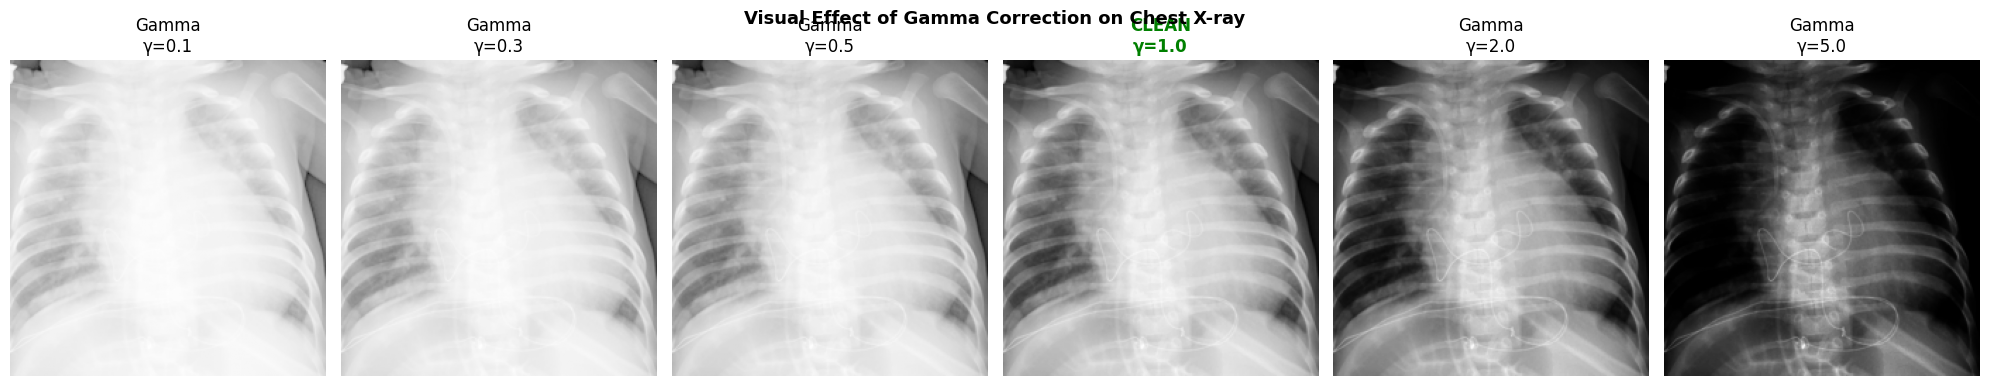

In [30]:
# Visualize gamma correction effects
viz_gammas = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
fig.suptitle('Visual Effect of Gamma Correction on Chest X-ray',
             fontsize=13, fontweight='bold')

for i, gamma in enumerate(viz_gammas):
    perturbed = gamma_attack(sample_img, gamma)
    img_display = denormalize(perturbed.squeeze().cpu())[0]
    axes[i].imshow(img_display, cmap='gray')
    if gamma == 1.0:
        axes[i].set_title(f'CLEAN\nγ={gamma:.1f}', color='green', fontweight='bold')
    else:
        axes[i].set_title(f'Gamma\nγ={gamma:.1f}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('gamma_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
def local_brightness_attack(images, delta, region='center'):
    """
    Applies brightness shift only to a specific region of the image.
    Mimics a localized scanner artifact.
    """
    perturbed = images.clone()
    _, _, H, W = images.shape

    if region == 'center':
        # Attack the center region where lungs typically are
        h_start, h_end = H//4, 3*H//4
        w_start, w_end = W//4, 3*W//4
    elif region == 'left':
        h_start, h_end = 0, H
        w_start, w_end = 0, W//2
    elif region == 'right':
        h_start, h_end = 0, H
        w_start, w_end = W//2, W

    perturbed[:, :, h_start:h_end, w_start:w_end] += delta
    return torch.clamp(perturbed, -1, 1)

print('Local brightness attack defined!')

Local brightness attack defined!


In [32]:
# compare regional attacks

regions = ['center', 'left', 'right']

for region in regions:
    def regional_attack(images, delta, r=region):
        return local_brightness_attack(images, delta, region=r)

    auc, acc, _, _ = evaluate(model, test_loader,
                               attack_fn=regional_attack,
                               attack_param=0.4)
    print(f'Region={region:8s} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Region=center   — AUC: 0.9209 | ACC: 0.6667
Region=left     — AUC: 0.9356 | ACC: 0.8237
Region=right    — AUC: 0.9366 | ACC: 0.8061


In [33]:
#stretch only the high or low end of the contrast range
def contrast_stretch_attack(images, params):
    """
    Clips pixel values at low and high percentiles then rescales.
    Simulates overexposure or underexposure of specific tonal ranges.
    """
    low_clip, high_clip = params  # Unpack the tuple
    perturbed = images.clone()
    perturbed = torch.clamp(perturbed, low_clip, high_clip)
    # Rescale back to [-1, 1]
    perturbed = (perturbed - low_clip) / (high_clip - low_clip) * 2 - 1
    return perturbed

print('Contrast stretching defined!')

Contrast stretching defined!


In [34]:
auc, acc, _, _ = evaluate(model, test_loader,
                           attack_fn=contrast_stretch_attack,
                           attack_param=(-0.5, 0.5))
print(f'Contrast stretch [-0.5, 0.5] — AUC: {auc:.4f} | ACC: {acc:.4f}')

Contrast stretch [-0.5, 0.5] — AUC: 0.9391 | ACC: 0.8558


In [35]:
clip_ranges = [(-0.8, 0.8), (-0.5, 0.5), (-0.3, 0.3), (-0.1, 0.1)]

for low, high in clip_ranges:
    auc, acc, _, _ = evaluate(model, test_loader,
                               attack_fn=contrast_stretch_attack,
                               attack_param=(low, high))
    print(f'Clip [{low:.1f}, {high:.1f}] — AUC: {auc:.4f} | ACC: {acc:.4f}')

Clip [-0.8, 0.8] — AUC: 0.9519 | ACC: 0.8734
Clip [-0.5, 0.5] — AUC: 0.9391 | ACC: 0.8558
Clip [-0.3, 0.3] — AUC: 0.9089 | ACC: 0.7853
Clip [-0.1, 0.1] — AUC: 0.8842 | ACC: 0.7740


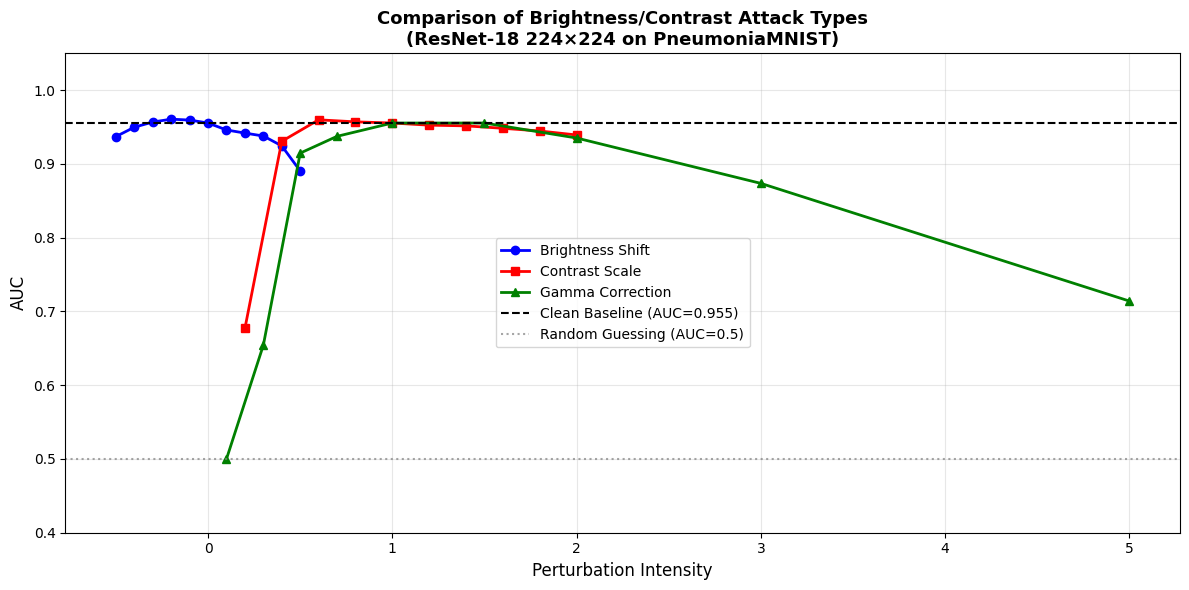

In [36]:
# comparing all attacks

# Ensure brightness_aucs and brightness_accs have the correct length
# This is a defensive measure in case the attack evaluation cells are run multiple times
brightness_aucs = brightness_aucs[:len(brightness_deltas)]
brightness_accs = brightness_accs[:len(brightness_deltas)]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(brightness_deltas, brightness_aucs, 'b-o', label='Brightness Shift', linewidth=2)
ax.plot(contrast_alphas, contrast_aucs, 'r-s', label='Contrast Scale', linewidth=2)
ax.plot(gammas, gamma_aucs, 'g-^', label='Gamma Correction', linewidth=2)
ax.axhline(y=clean_auc, color='black', linestyle='--', label=f'Clean Baseline (AUC={clean_auc:.3f})')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, label='Random Guessing (AUC=0.5)')

ax.set_xlabel('Perturbation Intensity', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Comparison of Brightness/Contrast Attack Types\n(ResNet-18 224\u00d7224 on PneumoniaMNIST)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig('attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
print('=' * 70)
print('MODEL ROBUSTNESS SUMMARY')
print('=' * 70)

print(f'\nClean Baseline — AUC: {clean_auc:.4f} | ACC: {clean_acc:.4f}')
print()

# Brightness robustness
worst_brightness_auc = min(brightness_aucs)
worst_brightness_idx = brightness_aucs.index(worst_brightness_auc)
worst_brightness_delta = brightness_deltas[worst_brightness_idx]
worst_brightness_acc = brightness_accs[worst_brightness_idx]
print(f'Brightness Attack:')
print(f'  Worst AUC: {worst_brightness_auc:.4f} at δ={worst_brightness_delta:+.1f}')
print(f'  Worst ACC: {worst_brightness_acc:.4f}')
print(f'  AUC Drop:  {clean_auc - worst_brightness_auc:.4f}')
print(f'  ACC Drop:  {clean_acc - worst_brightness_acc:.4f}')
print(f'  Verdict:   {"ROBUST" if clean_auc - worst_brightness_auc < 0.05 else "VULNERABLE"}')

print()

# Contrast robustness
worst_contrast_auc = min(contrast_aucs)
worst_contrast_idx = contrast_aucs.index(worst_contrast_auc)
worst_contrast_alpha = contrast_alphas[worst_contrast_idx]
worst_contrast_acc = contrast_accs[worst_contrast_idx]
print(f'Contrast Attack:')
print(f'  Worst AUC: {worst_contrast_auc:.4f} at α={worst_contrast_alpha:.1f}')
print(f'  Worst ACC: {worst_contrast_acc:.4f}')
print(f'  AUC Drop:  {clean_auc - worst_contrast_auc:.4f}')
print(f'  ACC Drop:  {clean_acc - worst_contrast_acc:.4f}')
print(f'  Verdict:   {"ROBUST" if clean_auc - worst_contrast_auc < 0.05 else "VULNERABLE"}')

print()

# Gamma robustness
worst_gamma_auc = min(gamma_aucs)
worst_gamma_idx = gamma_aucs.index(worst_gamma_auc)
worst_gamma = gammas[worst_gamma_idx]
worst_gamma_acc = gamma_accs[worst_gamma_idx]
print(f'Gamma Attack:')
print(f'  Worst AUC: {worst_gamma_auc:.4f} at γ={worst_gamma:.1f}')
print(f'  Worst ACC: {worst_gamma_acc:.4f}')
print(f'  AUC Drop:  {clean_auc - worst_gamma_auc:.4f}')
print(f'  ACC Drop:  {clean_acc - worst_gamma_acc:.4f}')
print(f'  Verdict:   {"ROBUST" if clean_auc - worst_gamma_auc < 0.05 else "VULNERABLE"}')

print()
print('=' * 70)

MODEL ROBUSTNESS SUMMARY

Clean Baseline — AUC: 0.9553 | ACC: 0.8942

Brightness Attack:
  Worst AUC: 0.8903 at δ=+0.5
  Worst ACC: 0.7260
  AUC Drop:  0.0650
  ACC Drop:  0.1683
  Verdict:   VULNERABLE

Contrast Attack:
  Worst AUC: 0.6770 at α=0.2
  Worst ACC: 0.6266
  AUC Drop:  0.2783
  ACC Drop:  0.2676
  Verdict:   VULNERABLE

Gamma Attack:
  Worst AUC: 0.5000 at γ=0.1
  Worst ACC: 0.6250
  AUC Drop:  0.4553
  ACC Drop:  0.2692
  Verdict:   VULNERABLE



# Attacking by grids

In [38]:
def grid_region_attack(images, params):
    """
    Brightness attack on a specific region in a 3x3 grid.
    params = (row, col, delta)
    row/col: 0=top/left, 1=middle/center, 2=bottom/right
    """
    row, col, delta = params
    perturbed = images.clone()
    _, _, H, W = images.shape

    h_start = row * H // 3
    h_end = (row + 1) * H // 3
    w_start = col * W // 3
    w_end = (col + 1) * W // 3

    perturbed[:, :, h_start:h_end, w_start:w_end] += delta
    return torch.clamp(perturbed, -1, 1)

print('Grid region attack defined!')

Grid region attack defined!


In [39]:
def grid_gamma_attack(images, params):
    """
    Gamma correction attack on a specific grid region.
    params = (row, col, gamma)
    gamma < 1 = brightens dark areas
    gamma > 1 = darkens bright areas
    """
    row, col, gamma = params
    perturbed = images.clone()
    _, _, H, W = images.shape

    h_start = row * H // 3
    h_end = (row + 1) * H // 3
    w_start = col * W // 3
    w_end = (col + 1) * W // 3

    # Extract region
    region = perturbed[:, :, h_start:h_end, w_start:w_end]

    # Apply gamma correction to region only
    region_01 = (region + 1) / 2  # Convert to [0,1]
    region_gamma = torch.pow(region_01.clamp(min=1e-8), gamma)
    region_back = (region_gamma * 2 - 1)  # Convert back to [-1,1]

    perturbed[:, :, h_start:h_end, w_start:w_end] = region_back
    return torch.clamp(perturbed, -1, 1)

print('Grid gamma attack defined!')

Grid gamma attack defined!


In [40]:
def evaluate_medmnist(model, loader, split='test', attack_fn=None, attack_param=None):
    """
    Evaluates model using the official MedMNIST Evaluator.
    """
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            if attack_fn is not None:
                images = attack_fn(images, attack_param)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Use size=224 to match native 224x224 dataset
    evaluator = Evaluator('pneumoniamnist', split, size=224)
    metrics = evaluator.evaluate(all_probs)

    auc = float(metrics.AUC)
    acc = float(metrics.ACC)

    return auc, acc

print('MedMNIST evaluator defined!')

MedMNIST evaluator defined!


In [41]:
brightness_deltas = [-0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

row_labels = ['Top', 'Middle', 'Bottom']
col_labels = ['Left', 'Center', 'Right']

# Store both AUC and ACC per region
grid_brightness_aucs = [[[] for _ in range(3)] for _ in range(3)]
grid_brightness_accs = [[[] for _ in range(3)] for _ in range(3)]

print('Running brightness sweep on each grid region...')
print('=' * 60)

for row in range(3):
    for col in range(3):
        print(f'\nRegion: {row_labels[row]} {col_labels[col]}')
        for delta in brightness_deltas:
            auc, acc = evaluate_medmnist(
                model, test_loader, split='test',
                attack_fn=grid_region_attack,
                attack_param=(row, col, delta)
            )
            grid_brightness_aucs[row][col].append(auc)
            grid_brightness_accs[row][col].append(acc)
            print(f'  δ={delta:+.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

print('\nBrightness sweep complete!')

Running brightness sweep on each grid region...

Region: Top Left
  δ=-0.5 — AUC: 0.9390 | ACC: 0.8269
  δ=-0.4 — AUC: 0.9365 | ACC: 0.8397
  δ=-0.3 — AUC: 0.9415 | ACC: 0.8478
  δ=-0.2 — AUC: 0.9487 | ACC: 0.8590
  δ=-0.1 — AUC: 0.9519 | ACC: 0.8766
  δ=+0.0 — AUC: 0.9553 | ACC: 0.8942
  δ=+0.1 — AUC: 0.9551 | ACC: 0.8958
  δ=+0.2 — AUC: 0.9525 | ACC: 0.8990
  δ=+0.3 — AUC: 0.9531 | ACC: 0.8990
  δ=+0.4 — AUC: 0.9526 | ACC: 0.8974
  δ=+0.5 — AUC: 0.9505 | ACC: 0.8958

Region: Top Center
  δ=-0.5 — AUC: 0.9525 | ACC: 0.8718
  δ=-0.4 — AUC: 0.9536 | ACC: 0.8878
  δ=-0.3 — AUC: 0.9557 | ACC: 0.8974
  δ=-0.2 — AUC: 0.9567 | ACC: 0.9022
  δ=-0.1 — AUC: 0.9570 | ACC: 0.9022
  δ=+0.0 — AUC: 0.9553 | ACC: 0.8942
  δ=+0.1 — AUC: 0.9534 | ACC: 0.8782
  δ=+0.2 — AUC: 0.9489 | ACC: 0.8590
  δ=+0.3 — AUC: 0.9459 | ACC: 0.8526
  δ=+0.4 — AUC: 0.9420 | ACC: 0.8510
  δ=+0.5 — AUC: 0.9373 | ACC: 0.8510

Region: Top Right
  δ=-0.5 — AUC: 0.9459 | ACC: 0.8494
  δ=-0.4 — AUC: 0.9478 | ACC: 0.8478
  δ=-0.

In [42]:
def grid_contrast_attack(images, params):
    """
    Contrast attack on a specific region in a 3x3 grid.
    params = (row, col, alpha)
    alpha > 1 = more contrast, alpha < 1 = less contrast
    """
    row, col, alpha = params
    perturbed = images.clone()
    _, _, H, W = images.shape

    h_start = row * H // 3
    h_end = (row + 1) * H // 3
    w_start = col * W // 3
    w_end = (col + 1) * W // 3

    # Apply contrast scaling to region only
    perturbed[:, :, h_start:h_end, w_start:w_end] *= alpha
    return torch.clamp(perturbed, -1, 1)

print('Grid contrast attack defined!')

Grid contrast attack defined!


In [43]:
contrast_alphas = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

grid_contrast_aucs = [[[] for _ in range(3)] for _ in range(3)]
grid_contrast_accs = [[[] for _ in range(3)] for _ in range(3)]

print('Running contrast sweep on each grid region...')
print('=' * 60)

for row in range(3):
    for col in range(3):
        print(f'\nRegion: {row_labels[row]} {col_labels[col]}')
        for alpha in contrast_alphas:
            auc, acc = evaluate_medmnist(
                model, test_loader, split='test',
                attack_fn=grid_contrast_attack,
                attack_param=(row, col, alpha)
            )
            grid_contrast_aucs[row][col].append(auc)
            grid_contrast_accs[row][col].append(acc)
            print(f'  α={alpha:.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

print('\nContrast sweep complete!')

Running contrast sweep on each grid region...

Region: Top Left
  α=0.2 — AUC: 0.9354 | ACC: 0.8558
  α=0.4 — AUC: 0.9401 | ACC: 0.8638
  α=0.6 — AUC: 0.9450 | ACC: 0.8782
  α=0.8 — AUC: 0.9501 | ACC: 0.8878
  α=1.0 — AUC: 0.9553 | ACC: 0.8942
  α=1.2 — AUC: 0.9576 | ACC: 0.8974
  α=1.4 — AUC: 0.9598 | ACC: 0.8990
  α=1.6 — AUC: 0.9594 | ACC: 0.8958
  α=1.8 — AUC: 0.9579 | ACC: 0.9006
  α=2.0 — AUC: 0.9572 | ACC: 0.8958

Region: Top Center
  α=0.2 — AUC: 0.9592 | ACC: 0.8814
  α=0.4 — AUC: 0.9589 | ACC: 0.8830
  α=0.6 — AUC: 0.9553 | ACC: 0.8958
  α=0.8 — AUC: 0.9566 | ACC: 0.8990
  α=1.0 — AUC: 0.9553 | ACC: 0.8942
  α=1.2 — AUC: 0.9521 | ACC: 0.8862
  α=1.4 — AUC: 0.9492 | ACC: 0.8798
  α=1.6 — AUC: 0.9489 | ACC: 0.8782
  α=1.8 — AUC: 0.9462 | ACC: 0.8782
  α=2.0 — AUC: 0.9437 | ACC: 0.8798

Region: Top Right
  α=0.2 — AUC: 0.9526 | ACC: 0.8686
  α=0.4 — AUC: 0.9535 | ACC: 0.8766
  α=0.6 — AUC: 0.9538 | ACC: 0.8814
  α=0.8 — AUC: 0.9539 | ACC: 0.8846
  α=1.0 — AUC: 0.9553 | ACC: 0.89

In [44]:
def grid_combined_attack(images, params):
    """
    Combined brightness + contrast attack on a specific region in a 3x3 grid.
    params = (row, col, delta, alpha)
    delta: brightness shift
    alpha: contrast scale
    """
    row, col, delta, alpha = params
    perturbed = images.clone()
    _, _, H, W = images.shape

    h_start = row * H // 3
    h_end = (row + 1) * H // 3
    w_start = col * W // 3
    w_end = (col + 1) * W // 3

    # Apply combined attack to region only
    region = perturbed[:, :, h_start:h_end, w_start:w_end]
    perturbed[:, :, h_start:h_end, w_start:w_end] = torch.clamp(
        alpha * region + delta, -1, 1
    )
    return perturbed

print('Grid combined attack defined!')

Grid combined attack defined!


In [45]:
# Fixed combined parameters to sweep
combined_deltas = [-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3]
combined_alpha = 0.6  # Fixed contrast while sweeping brightness

# Store results
grid_combined_sweep_aucs = [[[] for _ in range(3)] for _ in range(3)]

print('Running combined sweep on each grid region...')
print('=' * 60)

for row in range(3):
    for col in range(3):
        print(f'\nRegion: {row_labels[row]} {col_labels[col]}')
        for delta in combined_deltas:
            auc, acc = evaluate_medmnist(
                model, test_loader, split='test',
                attack_fn=grid_combined_attack,
                attack_param=(row, col, delta, combined_alpha)
            )
            grid_combined_sweep_aucs[row][col].append(auc)
            print(f'  δ={delta:+.1f}, α={combined_alpha} — AUC: {auc:.4f}')

Running combined sweep on each grid region...

Region: Top Left
  δ=-0.3, α=0.6 — AUC: 0.9356
  δ=-0.2, α=0.6 — AUC: 0.9423
  δ=-0.1, α=0.6 — AUC: 0.9456
  δ=+0.0, α=0.6 — AUC: 0.9450
  δ=+0.1, α=0.6 — AUC: 0.9465
  δ=+0.2, α=0.6 — AUC: 0.9431
  δ=+0.3, α=0.6 — AUC: 0.9440

Region: Top Center
  δ=-0.3, α=0.6 — AUC: 0.9564
  δ=-0.2, α=0.6 — AUC: 0.9579
  δ=-0.1, α=0.6 — AUC: 0.9572
  δ=+0.0, α=0.6 — AUC: 0.9553
  δ=+0.1, α=0.6 — AUC: 0.9555
  δ=+0.2, α=0.6 — AUC: 0.9540
  δ=+0.3, α=0.6 — AUC: 0.9511

Region: Top Right
  δ=-0.3, α=0.6 — AUC: 0.9472
  δ=-0.2, α=0.6 — AUC: 0.9494
  δ=-0.1, α=0.6 — AUC: 0.9516
  δ=+0.0, α=0.6 — AUC: 0.9538
  δ=+0.1, α=0.6 — AUC: 0.9550
  δ=+0.2, α=0.6 — AUC: 0.9564
  δ=+0.3, α=0.6 — AUC: 0.9557

Region: Middle Left
  δ=-0.3, α=0.6 — AUC: 0.9540
  δ=-0.2, α=0.6 — AUC: 0.9552
  δ=-0.1, α=0.6 — AUC: 0.9570
  δ=+0.0, α=0.6 — AUC: 0.9570
  δ=+0.1, α=0.6 — AUC: 0.9561
  δ=+0.2, α=0.6 — AUC: 0.9546
  δ=+0.3, α=0.6 — AUC: 0.9539

Region: Middle Center
  δ=-0.3, α=0

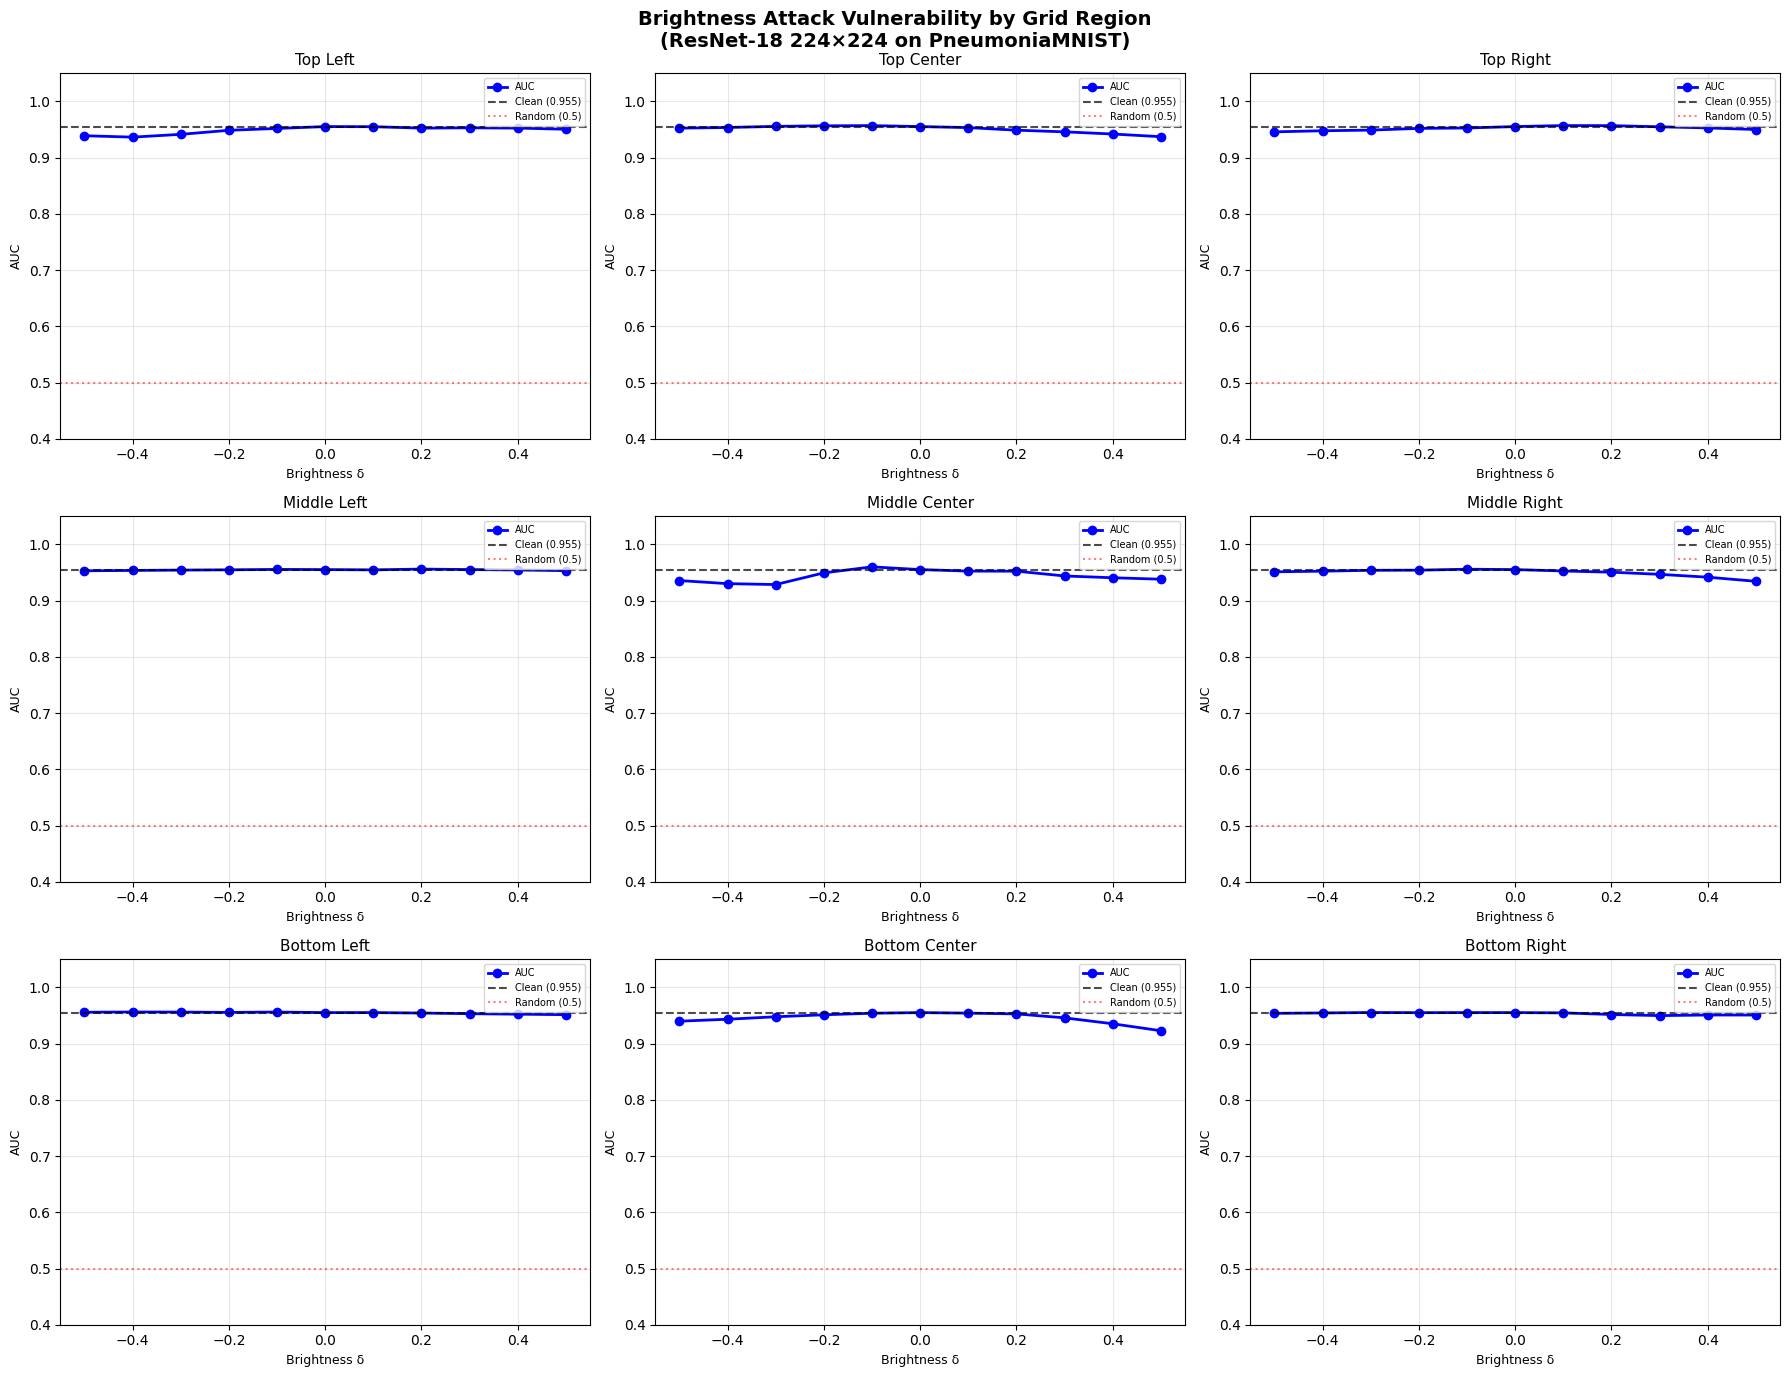

Grid brightness vulnerability curves saved!


In [46]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Brightness Attack Vulnerability by Grid Region\n(ResNet-18 224×224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.plot(brightness_deltas, grid_brightness_aucs[row][col],
                'b-o', linewidth=2, label='AUC')
        ax.axhline(y=clean_auc, color='black', linestyle='--',
                   alpha=0.7, label=f'Clean ({clean_auc:.3f})')
        ax.axhline(y=0.5, color='red', linestyle=':',
                   alpha=0.5, label='Random (0.5)')
        ax.set_title(f'{row_labels[row]} {col_labels[col]}', fontsize=11)
        ax.set_xlabel('Brightness δ', fontsize=9)
        ax.set_ylabel('AUC', fontsize=9)
        ax.set_ylim(0.4, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grid_brightness_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grid brightness vulnerability curves saved!')

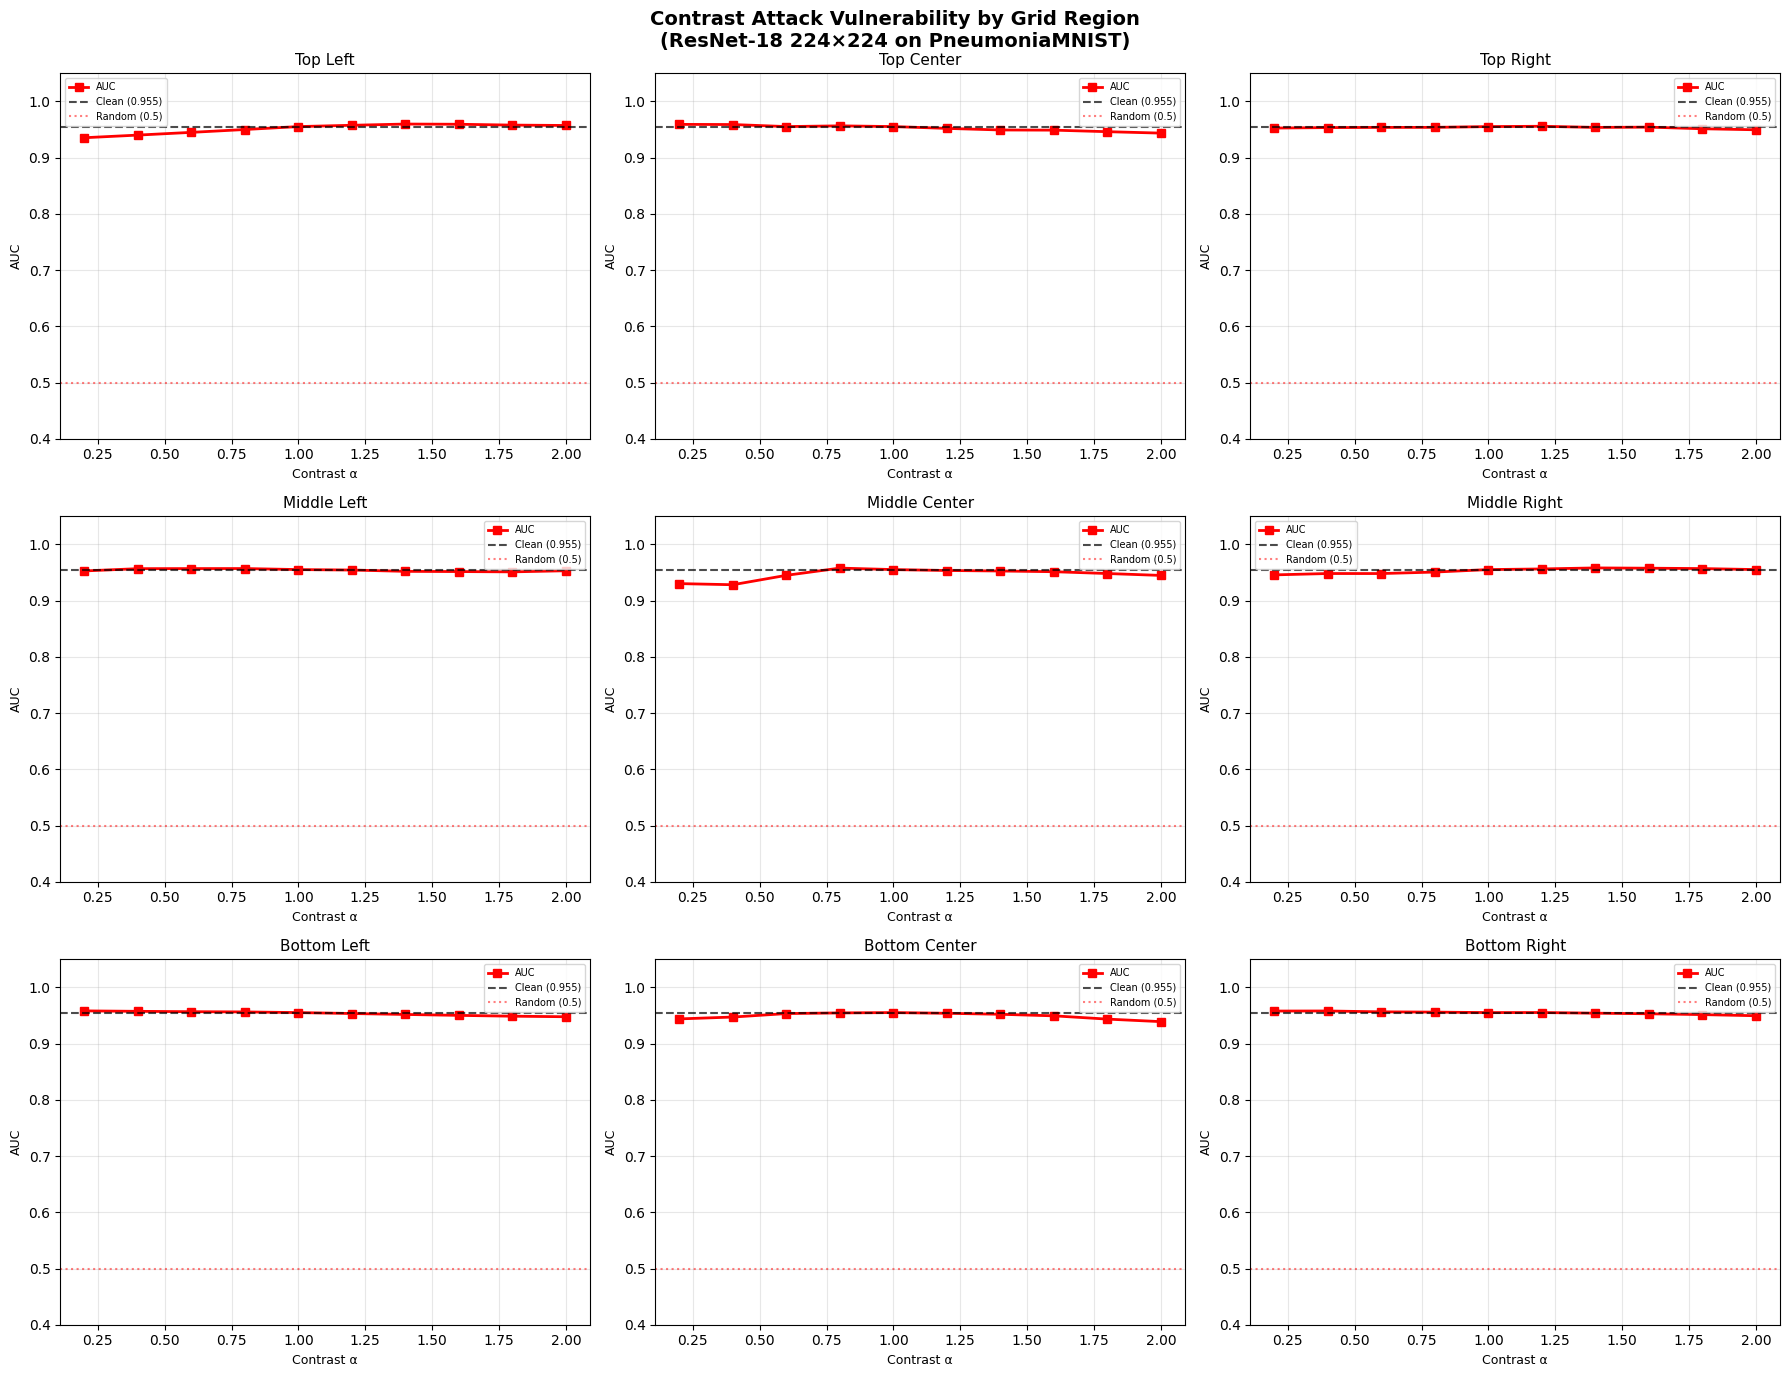

Grid contrast vulnerability curves saved!


In [47]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Contrast Attack Vulnerability by Grid Region\n(ResNet-18 224×224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.plot(contrast_alphas, grid_contrast_aucs[row][col],
                'r-s', linewidth=2, label='AUC')
        ax.axhline(y=clean_auc, color='black', linestyle='--',
                   alpha=0.7, label=f'Clean ({clean_auc:.3f})')
        ax.axhline(y=0.5, color='red', linestyle=':',
                   alpha=0.5, label='Random (0.5)')
        ax.set_title(f'{row_labels[row]} {col_labels[col]}', fontsize=11)
        ax.set_xlabel('Contrast α', fontsize=9)
        ax.set_ylabel('AUC', fontsize=9)
        ax.set_ylim(0.4, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grid_contrast_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grid contrast vulnerability curves saved!')

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

gammas = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]

grid_gamma_results = [[[] for _ in range(3)] for _ in range(3)]

print('Running gamma sweep on each grid region...')
print('=' * 70)

for row in range(3):
    for col in range(3):
        print(f'\nRegion: {row_labels[row]} {col_labels[col]}')
        print(f'{"Gamma":>8} | {"AUC":>8} | {"ACC":>8} | {"Precision":>10} | {"Recall":>8} | {"F1":>8}')
        print('-' * 70)

        for gamma in gammas:
            auc, acc, labels, preds = evaluate(
                model, test_loader,
                attack_fn=grid_gamma_attack,
                attack_param=(row, col, gamma)
            )

            precision = precision_score(labels, preds, zero_division=0)
            recall = recall_score(labels, preds, zero_division=0)
            f1 = f1_score(labels, preds, zero_division=0)

            grid_gamma_results[row][col].append({
                'gamma': gamma,
                'auc': auc,
                'acc': acc,
                'precision': precision,
                'recall': recall,
                'f1': f1
            })

            print(f'{gamma:>8.1f} | {auc:>8.4f} | {acc:>8.4f} | {precision:>10.4f} | {recall:>8.4f} | {f1:>8.4f}')

print('\nGamma sweep complete!')

Running gamma sweep on each grid region...

Region: Top Left
   Gamma |      AUC |      ACC |  Precision |   Recall |       F1
----------------------------------------------------------------------
     0.1 |   0.9416 |   0.8958 |     0.8878 |   0.9538 |   0.9197
     0.3 |   0.9468 |   0.8894 |     0.8690 |   0.9692 |   0.9164
     0.5 |   0.9468 |   0.8878 |     0.8687 |   0.9667 |   0.9150
     0.7 |   0.9496 |   0.8894 |     0.8707 |   0.9667 |   0.9162
     1.0 |   0.9553 |   0.8942 |     0.8716 |   0.9744 |   0.9201
     1.5 |   0.9471 |   0.8542 |     0.8161 |   0.9897 |   0.8946
     2.0 |   0.9404 |   0.8365 |     0.7975 |   0.9897 |   0.8833
     3.0 |   0.9398 |   0.8173 |     0.7738 |   1.0000 |   0.8725
     5.0 |   0.9377 |   0.8029 |     0.7602 |   1.0000 |   0.8638

Region: Top Center
   Gamma |      AUC |      ACC |  Precision |   Recall |       F1
----------------------------------------------------------------------
     0.1 |   0.9225 |   0.8173 |     0.7828 |   0.9

In [49]:
from sklearn.metrics import f1_score

# Calculate clean baseline F1-score for reference in plots
clean_preds_f1 = f1_score(clean_labels, clean_preds, zero_division=0)
print(f'Clean Baseline F1-Score: {clean_preds_f1:.4f}')

Clean Baseline F1-Score: 0.9201


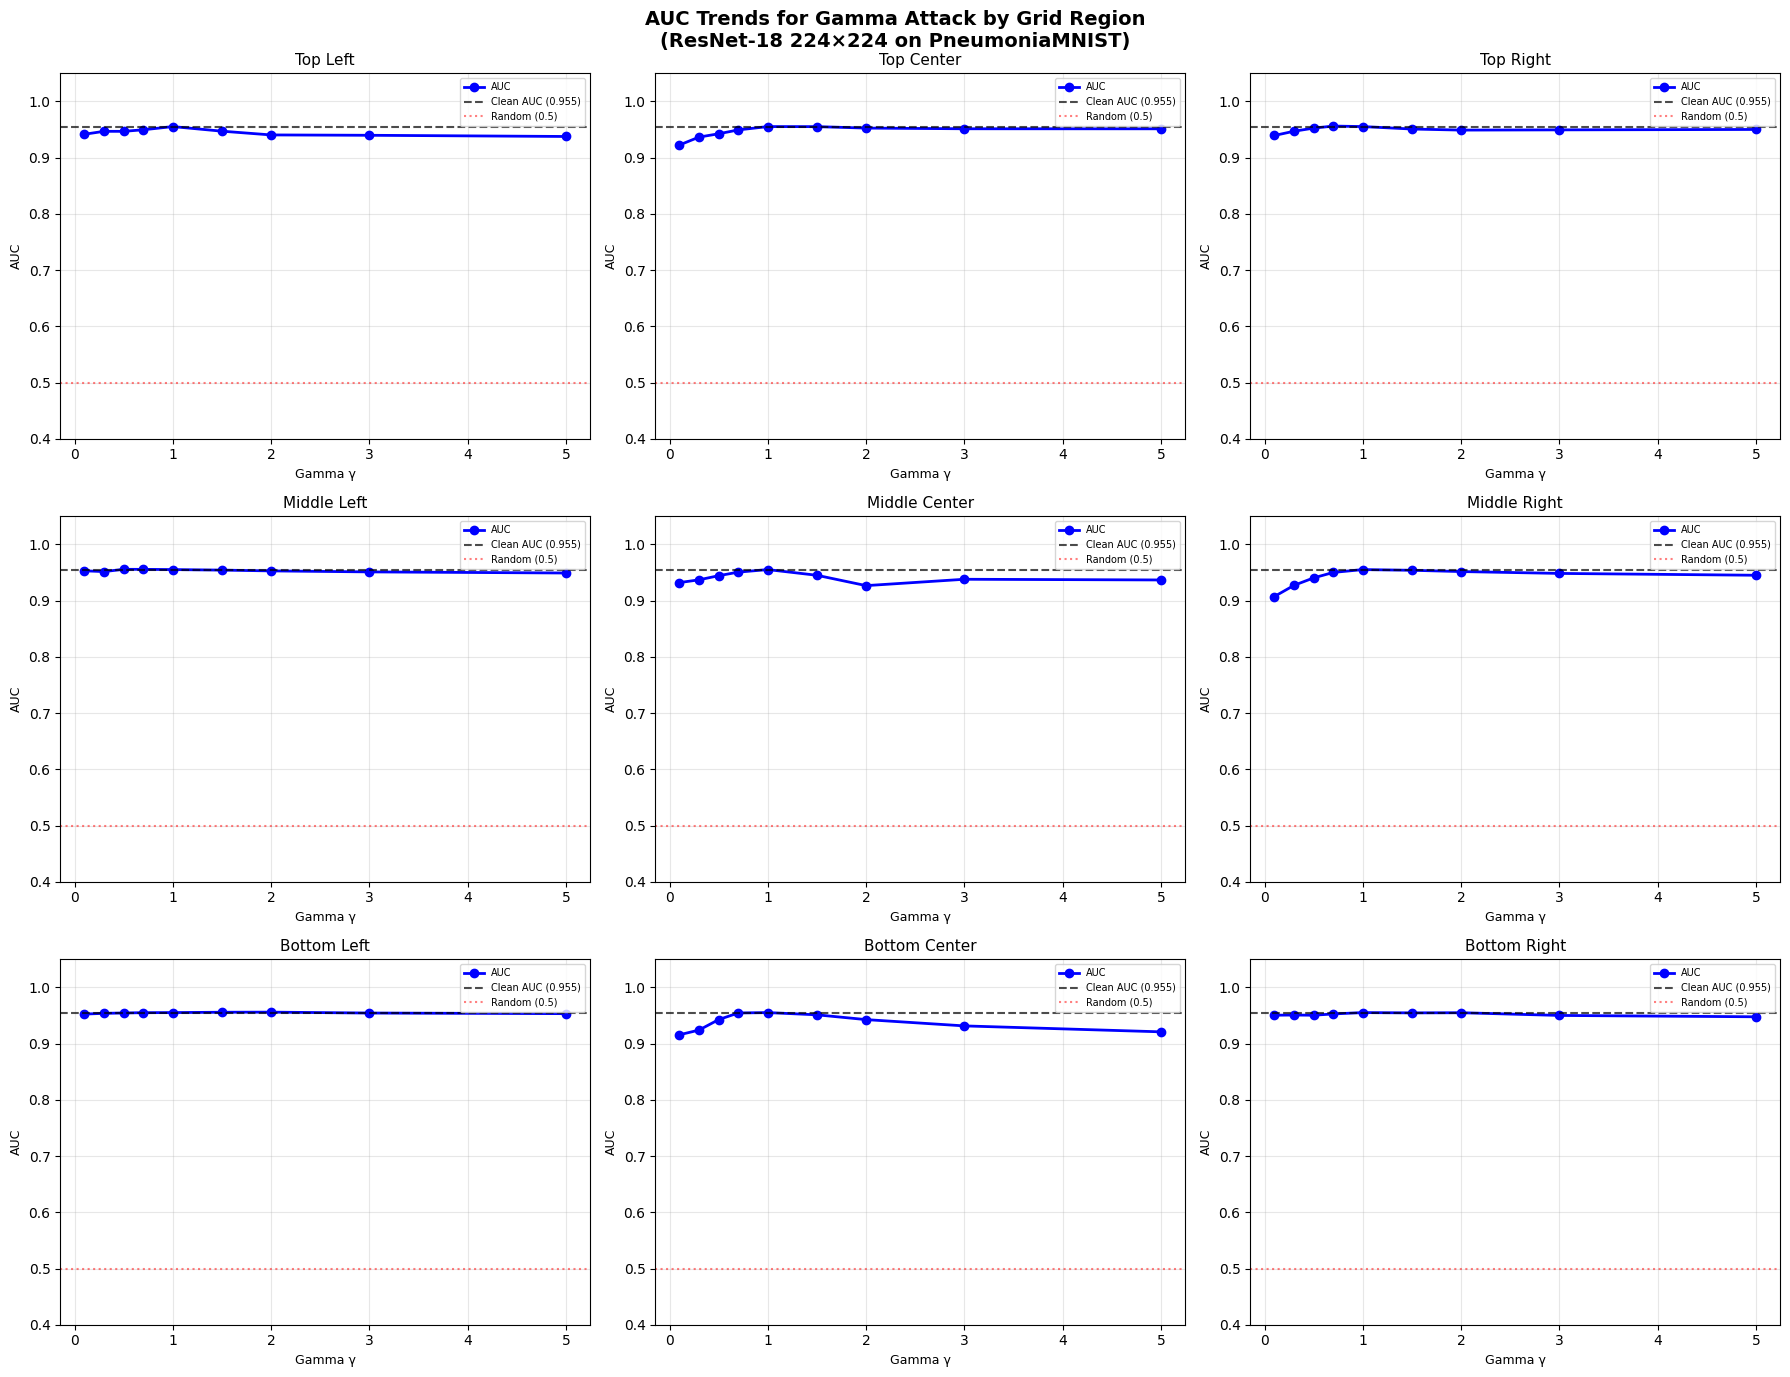

Grid gamma AUC vulnerability curves saved!


In [50]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('AUC Trends for Gamma Attack by Grid Region\n(ResNet-18 224\u00d7224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        aucs = [res['auc'] for res in grid_gamma_results[row][col]]
        ax.plot(gammas, aucs, 'b-o', linewidth=2, label='AUC')
        ax.axhline(y=clean_auc, color='black', linestyle='--', alpha=0.7, label=f'Clean AUC ({clean_auc:.3f})')
        ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='Random (0.5)')
        ax.set_title(f'{row_labels[row]} {col_labels[col]}', fontsize=11)
        ax.set_xlabel('Gamma \u03b3', fontsize=9)
        ax.set_ylabel('AUC', fontsize=9)
        ax.set_ylim(0.4, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grid_gamma_auc_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grid gamma AUC vulnerability curves saved!')

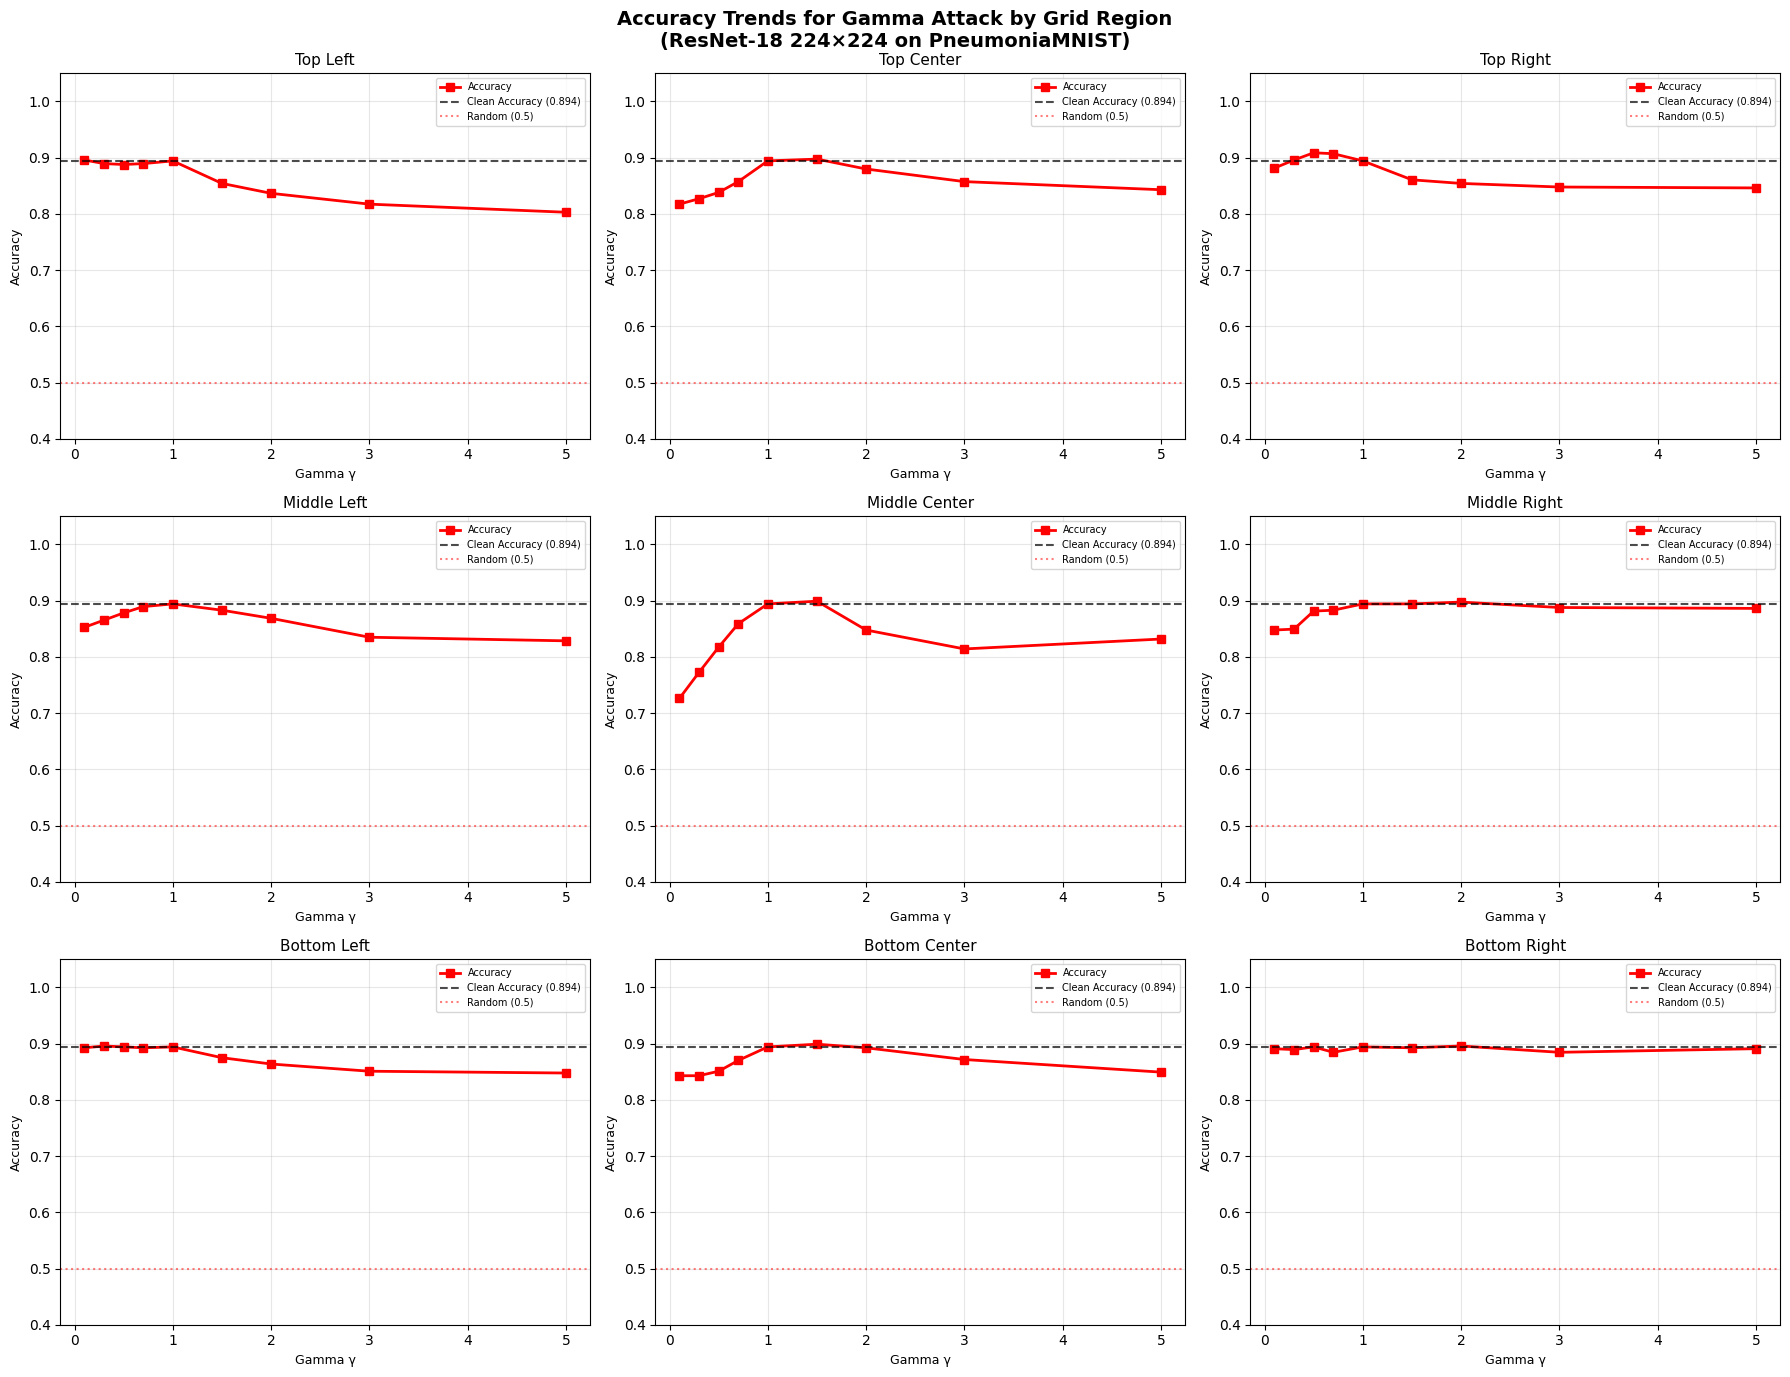

Grid gamma Accuracy vulnerability curves saved!


In [51]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Accuracy Trends for Gamma Attack by Grid Region\n(ResNet-18 224\u00d7224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        accs = [res['acc'] for res in grid_gamma_results[row][col]]
        ax.plot(gammas, accs, 'r-s', linewidth=2, label='Accuracy')
        ax.axhline(y=clean_acc, color='black', linestyle='--', alpha=0.7, label=f'Clean Accuracy ({clean_acc:.3f})')
        ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='Random (0.5)')
        ax.set_title(f'{row_labels[row]} {col_labels[col]}', fontsize=11)
        ax.set_xlabel('Gamma \u03b3', fontsize=9)
        ax.set_ylabel('Accuracy', fontsize=9)
        ax.set_ylim(0.4, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grid_gamma_acc_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grid gamma Accuracy vulnerability curves saved!')

In [52]:
shutil.copy('grid_gamma_auc_vulnerability.png',
            '/content/drive/MyDrive/resnet_18_weights_folder_iter1/grid_gamma_auc_vulnerability.png')
shutil.copy('grid_gamma_acc_vulnerability.png',
            '/content/drive/MyDrive/resnet_18_weights_folder_iter1/grid_gamma_acc_vulnerability.png')
print('Grid gamma AUC and Accuracy vulnerability curves copied to Drive!')

Grid gamma AUC and Accuracy vulnerability curves copied to Drive!


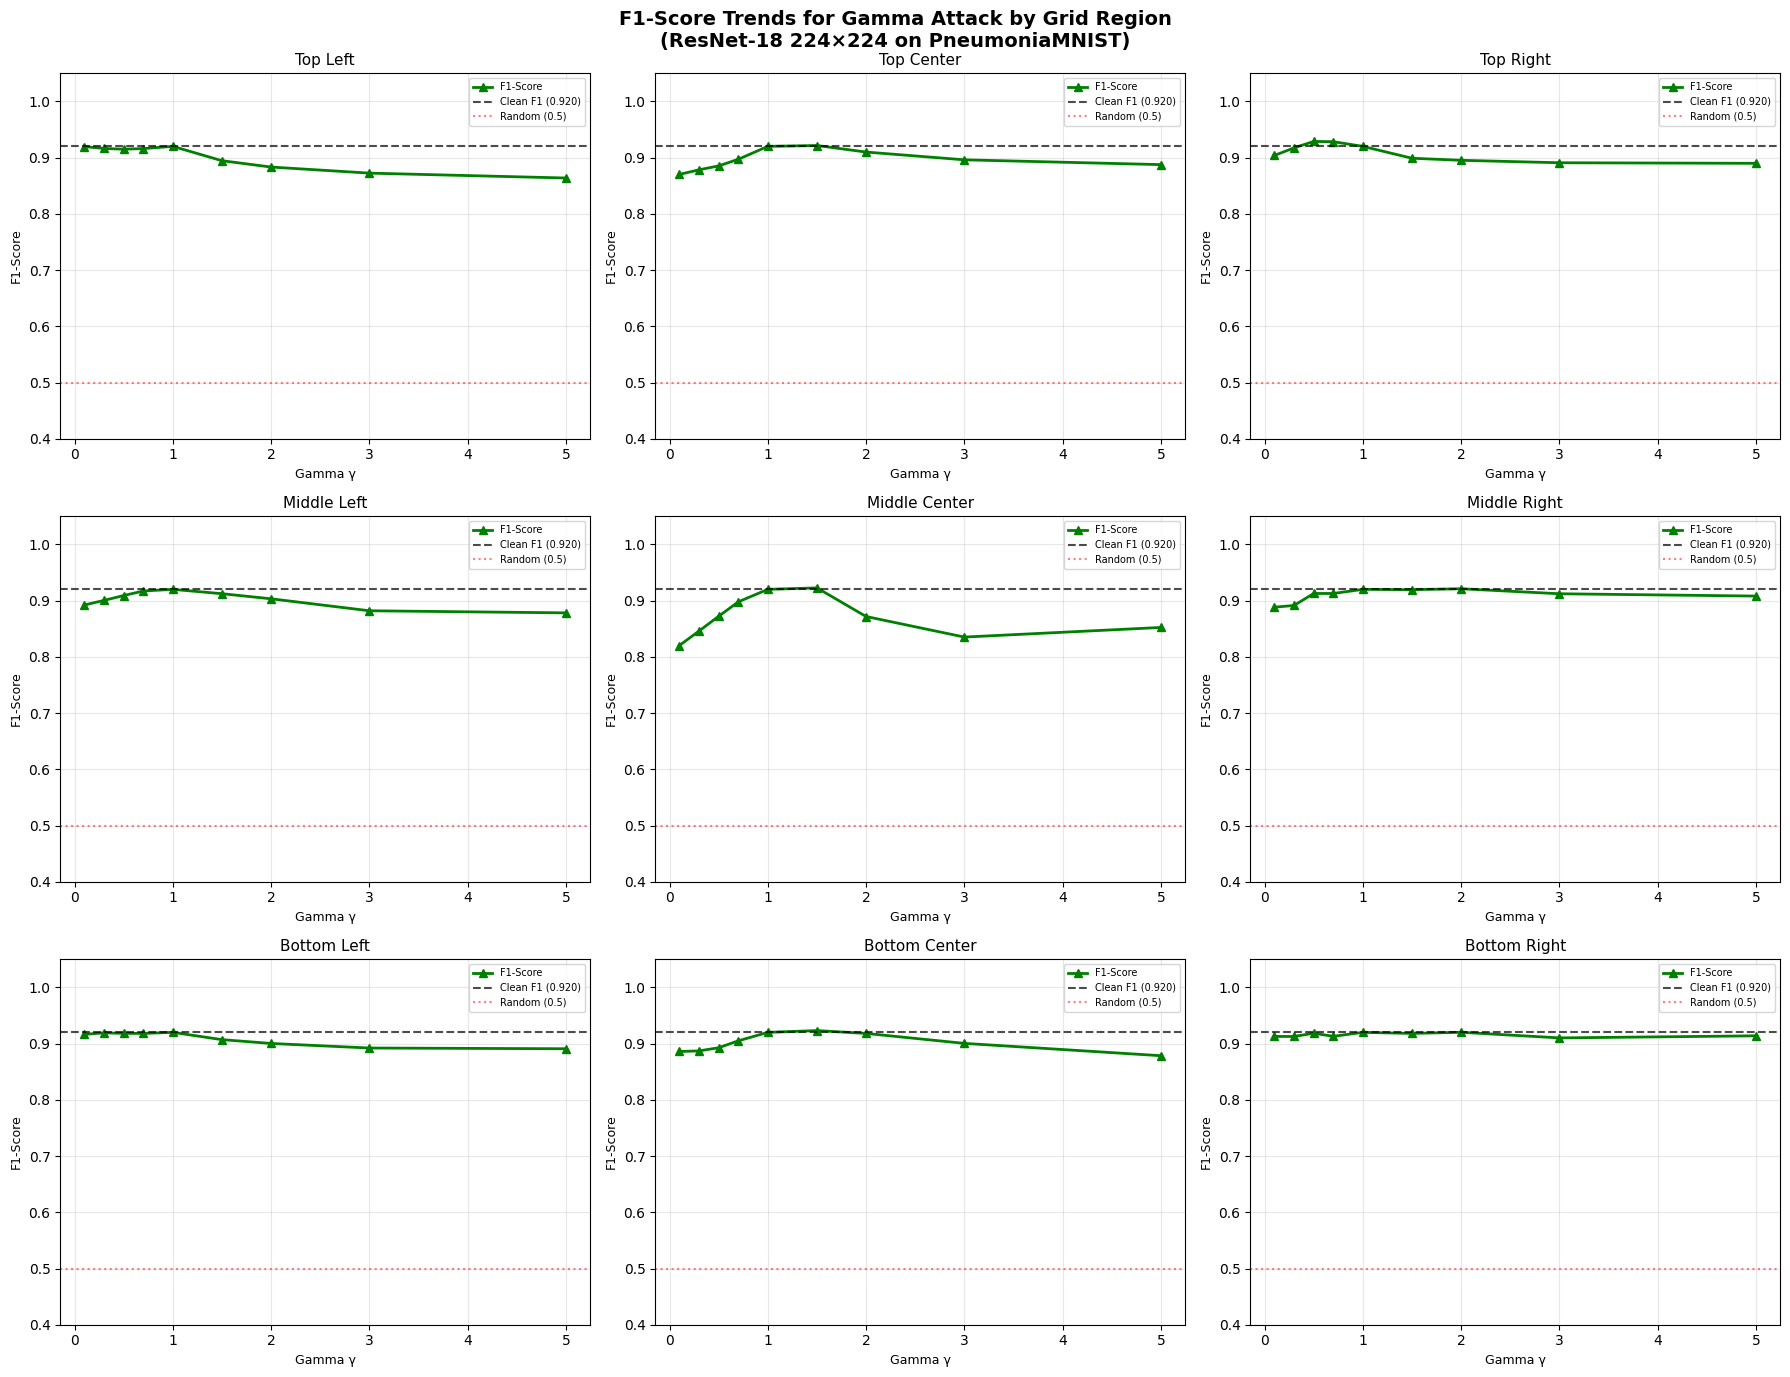

Grid gamma F1-score vulnerability curves saved!


In [53]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('F1-Score Trends for Gamma Attack by Grid Region\n(ResNet-18 224\u00d7224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        f1_scores = [res['f1'] for res in grid_gamma_results[row][col]]
        ax.plot(gammas, f1_scores, 'g-^', linewidth=2, label='F1-Score')
        ax.axhline(y=clean_preds_f1, color='black', linestyle='--', alpha=0.7, label=f'Clean F1 ({clean_preds_f1:.3f})')
        ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='Random (0.5)')
        ax.set_title(f'{row_labels[row]} {col_labels[col]}', fontsize=11)
        ax.set_xlabel('Gamma \u03b3', fontsize=9)
        ax.set_ylabel('F1-Score', fontsize=9)
        ax.set_ylim(0.4, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grid_gamma_f1_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grid gamma F1-score vulnerability curves saved!')

In [54]:
shutil.copy('grid_gamma_f1_vulnerability.png',
            '/content/drive/MyDrive/resnet_18_weights_folder_iter1/grid_gamma_f1_vulnerability.png')
print('Grid gamma F1-score vulnerability curves copied to Drive!')

Grid gamma F1-score vulnerability curves copied to Drive!


In [55]:
import shutil
shutil.copy('grid_brightness_vulnerability.png',
            '/content/drive/MyDrive/resnet_18_weights_folder_iter1/grid_brightness_vulnerability.png')
shutil.copy('grid_contrast_vulnerability.png',
            '/content/drive/MyDrive/resnet_18_weights_folder_iter1/grid_contrast_vulnerability.png')
print('All grid vulnerability curves saved to Drive!')

All grid vulnerability curves saved to Drive!


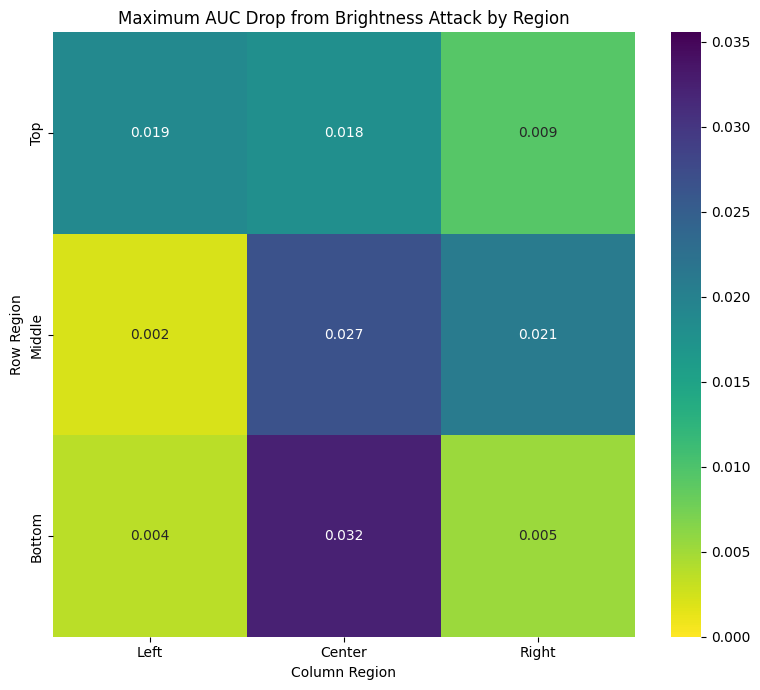

Maximum AUC drop heatmap for regional brightness attack saved!


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate AUC drops for brightness attacks
auc_drops_brightness = np.zeros((3, 3, len(brightness_deltas)))

for row in range(3):
    for col in range(3):
        for i, auc_val in enumerate(grid_brightness_aucs[row][col]):
            auc_drops_brightness[row, col, i] = clean_auc - auc_val

# Visualize the maximum AUC drop for each region across all deltas
max_auc_drop_per_region = np.max(auc_drops_brightness, axis=2)

plt.figure(figsize=(8, 7))
sns.heatmap(max_auc_drop_per_region,
            xticklabels=col_labels,
            yticklabels=row_labels,
            annot=True, fmt='.3f', cmap='viridis_r', # '_r' reverses the colormap, so larger drops are darker
            vmin=0, vmax=max_auc_drop_per_region.max() * 1.1)
plt.xlabel('Column Region')
plt.ylabel('Row Region')
plt.title('Maximum AUC Drop from Brightness Attack by Region')
plt.tight_layout()
plt.savefig('heatmap_max_brightness_auc_drop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Maximum AUC drop heatmap for regional brightness attack saved!')

This heatmap shows the *maximum* drop in AUC for each 3x3 region across all tested brightness deltas. A higher value indicates greater vulnerability in that specific region to brightness changes.

In [57]:
shutil.copy('heatmap_max_brightness_auc_drop.png',
            '/content/drive/MyDrive/resnet_18_weights_folder_iter1/heatmap_max_brightness_auc_drop.png')
print('Max brightness AUC drop heatmap copied to Drive!')

Max brightness AUC drop heatmap copied to Drive!


In [58]:
print('=' * 70)
print('GRID-BY-GRID ATTACK SUMMARY')
print('=' * 70)

# Helper to find worst performance
def find_worst_result(results_grid, parameter_list, metric_key='auc'):
    worst_value = float('inf')
    worst_region = None
    worst_param = None

    for row in range(3):
        for col in range(3):
            for i, result_data in enumerate(results_grid[row][col]):
                current_value = result_data if isinstance(result_data, (float, np.float64)) else result_data[metric_key]
                if current_value < worst_value:
                    worst_value = current_value
                    worst_region = (row_labels[row], col_labels[col])
                    worst_param = parameter_list[i]
    return worst_value, worst_region, worst_param

# Brightness Attack Summary
print('\n--- Brightness Attack ---\n')
all_brightness_aucs = [item for sublist in grid_brightness_aucs for sub_sublist in sublist for item in sub_sublist]
min_brightness_auc = min(all_brightness_aucs)

worst_brightness_region = None
worst_brightness_delta = None
for row in range(3):
    for col in range(3):
        for i, auc_val in enumerate(grid_brightness_aucs[row][col]):
            if auc_val == min_brightness_auc:
                worst_brightness_region = (row_labels[row], col_labels[col])
                worst_brightness_delta = brightness_deltas[i]
                break
        if worst_brightness_region: break
    if worst_brightness_region: break

print(f'Worst Brightness AUC: {min_brightness_auc:.4f} in region {worst_brightness_region[0]} {worst_brightness_region[1]} at delta={worst_brightness_delta:+.1f}')

# Contrast Attack Summary
print('\n--- Contrast Attack ---\n')
all_contrast_aucs = [item for sublist in grid_contrast_aucs for sub_sublist in sublist for item in sub_sublist]
min_contrast_auc = min(all_contrast_aucs)

worst_contrast_region = None
worst_contrast_alpha = None
for row in range(3):
    for col in range(3):
        for i, auc_val in enumerate(grid_contrast_aucs[row][col]):
            if auc_val == min_contrast_auc:
                worst_contrast_region = (row_labels[row], col_labels[col])
                worst_contrast_alpha = contrast_alphas[i]
                break
        if worst_contrast_region: break
    if worst_contrast_region: break

print(f'Worst Contrast AUC: {min_contrast_auc:.4f} in region {worst_contrast_region[0]} {worst_contrast_region[1]} at alpha={worst_contrast_alpha:.1f}')

# Gamma Attack Summary
print('\n--- Gamma Attack ---\n')
# For gamma, results_grid items are dicts, need to adapt find_worst_result

# Find worst AUC for Gamma
worst_gamma_auc, worst_gamma_auc_region, worst_gamma_auc_param = find_worst_result(grid_gamma_results, gammas, 'auc')
print(f'Worst Gamma AUC: {worst_gamma_auc:.4f} in region {worst_gamma_auc_region[0]} {worst_gamma_auc_region[1]} at gamma={worst_gamma_auc_param:.1f}')

# Find worst Accuracy for Gamma
worst_gamma_acc, worst_gamma_acc_region, worst_gamma_acc_param = find_worst_result(grid_gamma_results, gammas, 'acc')
print(f'Worst Gamma Accuracy: {worst_gamma_acc:.4f} in region {worst_gamma_acc_region[0]} {worst_gamma_acc_region[1]} at gamma={worst_gamma_acc_param:.1f}')

# Find worst F1-Score for Gamma
worst_gamma_f1, worst_gamma_f1_region, worst_gamma_f1_param = find_worst_result(grid_gamma_results, gammas, 'f1')
print(f'Worst Gamma F1-Score: {worst_gamma_f1:.4f} in region {worst_gamma_f1_region[0]} {worst_gamma_f1_region[1]} at gamma={worst_gamma_f1_param:.1f}')

print('\n' + '=' * 70)

GRID-BY-GRID ATTACK SUMMARY

--- Brightness Attack ---

Worst Brightness AUC: 0.9230 in region Bottom Center at delta=+0.5

--- Contrast Attack ---

Worst Contrast AUC: 0.9283 in region Middle Center at alpha=0.4

--- Gamma Attack ---

Worst Gamma AUC: 0.9073 in region Middle Right at gamma=0.1
Worst Gamma Accuracy: 0.7260 in region Middle Center at gamma=0.1
Worst Gamma F1-Score: 0.8202 in region Middle Center at gamma=0.1



In [59]:
import pandas as pd

# Data collected from the summary output
summary_data = {
    'Attack Type': ['Brightness (AUC)', 'Brightness (Accuracy)', 'Contrast (AUC)', 'Contrast (Accuracy)', 'Gamma (AUC)', 'Gamma (Accuracy)', 'Gamma (F1-Score)'],
    'Worst Metric Value': [
        worst_brightness_auc,
        worst_brightness_acc,
        worst_contrast_auc,
        worst_contrast_acc,
        worst_gamma_auc,
        worst_gamma_acc,
        worst_gamma_f1
    ],
    'Metric': [
        'AUC',
        'Accuracy',
        'AUC',
        'Accuracy',
        'AUC',
        'Accuracy',
        'F1-Score'
    ],
    'Worst Parameter': [
        f'delta={worst_brightness_delta:+.1f}',
        f'delta={worst_brightness_delta:+.1f}',
        f'alpha={worst_contrast_alpha:.1f}',
        f'alpha={worst_contrast_alpha:.1f}',
        f'gamma={worst_gamma_auc_param:.1f}',
        f'gamma={worst_gamma_acc_param:.1f}',
        f'gamma={worst_gamma_f1_param:.1f}'
    ],
    'Worst Region': [
        'Global (Worst-Case)',
        'Global (Worst-Case)',
        'Global (Worst-Case)',
        'Global (Worst-Case)',
        f'{worst_gamma_auc_region[0]} {worst_gamma_auc_region[1]}',
        f'{worst_gamma_acc_region[0]} {worst_gamma_acc_region[1]}',
        f'{worst_gamma_f1_region[0]} {worst_gamma_f1_region[1]}'
    ]
}

summary_df = pd.DataFrame(summary_data)

print('\nWorst-Case Attack Summary Table:')
display(summary_df)


Worst-Case Attack Summary Table:


,Attack Type,Worst Metric Value,Metric,Worst Parameter,Worst Region
0,Brightness (AUC),0.890286,AUC,delta=+0.5,Global (Worst-Case)
1,Brightness (Accuracy),0.725962,Accuracy,delta=+0.5,Global (Worst-Case)
2,Contrast (AUC),0.677022,AUC,alpha=0.4,Global (Worst-Case)
3,Contrast (Accuracy),0.626603,Accuracy,alpha=0.4,Global (Worst-Case)
4,Gamma (AUC),0.907314,AUC,gamma=0.1,Middle Right
5,Gamma (Accuracy),0.725962,Accuracy,gamma=0.1,Middle Center
6,Gamma (F1-Score),0.820189,F1-Score,gamma=0.1,Middle Center
